
# 01 – Financial Data Preparation & Baseline Modelling

This notebook prepares the **financial dataset** and estimates **baseline ARX / VAR models** without any emotion-based variables.

It:

1. Loads raw OHLCV financial data (Bitcoin, Gold, Crude Oil, S&P 500, FX, 10Y yield).
2. Cleans and aligns the series on a common daily index.
3. Constructs **log returns** and **control variables** (FX, oil, yield).
4. Performs basic exploratory analysis and stationarity checks.
5. Estimates baseline **ARX** (per asset) and a multivariate **VAR** model.
6. Exports a tidy dataset for use in the emotion/EPI notebook.

> **Note:** You may need to adjust file paths and column names to match your actual data.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import statsmodels.api as sm

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
FINANCIAL_PANEL_FILE = OUTPUT_DIR + "financial_returns_and_controls.parquet"
FINANCIAL_PANEL_CSV = OUTPUT_DIR + "financial_returns_and_controls.csv"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"



## 1. Load raw financial data

Expected structure (example):

```json
{
  "Date_": "2024-11-19 00:00:00",
  "Close_BTC-USD": ...,
  "High_BTC-USD": ...,
  "Low_BTC-USD": ...,
  "Open_BTC-USD": ...,
  "Volume_BTC-USD": ...,
  ...
}
```


In [2]:

# --- Load raw data ---
# If your file is CSV, use read_csv instead.
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Basic cleaning: parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    # Adjust here if your date column has a different name
    raise KeyError("Expected a 'Date_' column. Please adjust the code to your date column name.")

print(df_raw.head())
print(df_raw.info())


            Close_BTC-USD  Close_CL=F  Close_CNY=X  Close_EUR=X  Close_GC=F  \
Date_                                                                         
2024-11-18            NaN         NaN          NaN          NaN         NaN   
2024-11-19     92343.7891     69.3900       7.2354       0.9438   2627.1001   
2024-11-20     94339.4922     68.8700       7.2381       0.9427   2648.2000   
2024-11-21     98504.7266     70.1000       7.2440       0.9482   2672.1001   
2024-11-22     98997.6641     71.2400       7.2337       0.9552   2709.8999   

            Close_^GSPC  Close_^TNX  High_BTC-USD  High_CL=F  High_CNY=X  ...  \
Date_                                                                     ...   
2024-11-18          NaN      4.4140           NaN        NaN         NaN  ...   
2024-11-19    5916.9800      4.3790    94002.8672    69.6900      7.2428  ...   
2024-11-20    5917.1099      4.4060    94902.0234    70.1500      7.2461  ...   
2024-11-21    5948.7100      4.4320    99


## 2. Sanity checks & renaming

We rename columns to simpler names (e.g. `close_btc`, `close_gold`, etc.) so they are easier to work with.


In [3]:

# Inspect available columns
df_raw.columns


Index(['Close_BTC-USD', 'Close_CL=F', 'Close_CNY=X', 'Close_EUR=X',
       'Close_GC=F', 'Close_^GSPC', 'Close_^TNX', 'High_BTC-USD', 'High_CL=F',
       'High_CNY=X', 'High_EUR=X', 'High_GC=F', 'High_^GSPC', 'High_^TNX',
       'Low_BTC-USD', 'Low_CL=F', 'Low_CNY=X', 'Low_EUR=X', 'Low_GC=F',
       'Low_^GSPC', 'Low_^TNX', 'Open_BTC-USD', 'Open_CL=F', 'Open_CNY=X',
       'Open_EUR=X', 'Open_GC=F', 'Open_^GSPC', 'Open_^TNX', 'Volume_BTC-USD',
       'Volume_CL=F', 'Volume_CNY=X', 'Volume_EUR=X', 'Volume_GC=F',
       'Volume_^GSPC', 'Volume_^TNX'],
      dtype='object')

In [4]:

# Define a renaming map; extend / adjust as needed
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Open_BTC-USD": "open_btc",
    "High_BTC-USD": "high_btc",
    "Low_BTC-USD": "low_btc",
    "Volume_BTC-USD": "vol_btc",

    "Close_GC=F": "close_gold",
    "Open_GC=F": "open_gold",
    "High_GC=F": "high_gold",
    "Low_GC=F": "low_gold",
    "Volume_GC=F": "vol_gold",

    "Close_CL=F": "close_oil",
    "Open_CL=F": "open_oil",
    "High_CL=F": "high_oil",
    "Low_CL=F": "low_oil",
    "Volume_CL=F": "vol_oil",

    "Close_^GSPC": "close_spx",
    "Open_^GSPC": "open_spx",
    "High_^GSPC": "high_spx",
    "Low_^GSPC": "low_spx",
    "Volume_^GSPC": "vol_spx",

    "Close_CNY=X": "close_usdcny",
    "Open_CNY=X": "open_usdcny",
    "High_CNY=X": "high_usdcny",
    "Low_CNY=X": "low_usdcny",
    "Volume_CNY=X": "vol_usdcny",

    "Close_EUR=X": "close_eurusd",
    "Open_EUR=X": "open_eurusd",
    "High_EUR=X": "high_eurusd",
    "Low_EUR=X": "low_eurusd",
    "Volume_EUR=X": "vol_eurusd",

    "Close_^TNX": "close_ust10y",
    "Open_^TNX": "open_ust10y",
    "High_^TNX": "high_ust10y",
    "Low_^TNX": "low_ust10y",
    "Volume_^TNX": "vol_ust10y",
}

df = df_raw.rename(columns=rename_map)

print("After renaming:")
print(df.head())


After renaming:
            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
Date_                                                                      
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
Date_                                                                  ...   
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800     

## 3. Align frequencies and handle non-trading days

We keep the native trading-day calendar (no synthetic weekend/holiday rows). Prices are forward-filled within existing rows only, and a flag marks rows that needed filling.

In [5]:
# Create a continuous business-day index over the sample
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

# Identify price and volume columns
price_cols = [c for c in df.columns if c.startswith(("close_", "open_", "high_", "low_"))]
volume_cols = [c for c in df.columns if c.startswith("vol_")]

# Track rows where prices were missing prior to forward-fill
missing_price_rows = df[price_cols].isna().any(axis=1)

# Forward-fill prices, leave volumes as-is
df[price_cols] = df[price_cols].ffill()

# Flag rows that relied on forward-filled prices
df["ffill_flag"] = missing_price_rows

print(df.head())


            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800       7.2459  ...   
2024-11-22  5969.3398        4.4100 99655.5000   71.5100       7.2487  ...   

            open_spx  open_ust10y           vol_btc     vol_oil  vol_usdcn


## 4. Construct returns and control variables

We compute:

- **Log returns** for Bitcoin, Gold, S&P 500.
- **Log differences** for FX and oil.
- **First difference** for the 10-year yield.


In [6]:

def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

# Control variables
returns["dln_eurusd"] = log_return(df["close_eurusd"])   # USD/EUR
returns["dln_usdcny"] = log_return(df["close_usdcny"])   # USD/CNY
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs from differencing
returns = returns.dropna()

# Restrict to analysis window
returns = returns.loc[START_DATE:END_DATE]

returns.head()


,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10
2025-01-01,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-02,0.0258,0.0112,-0.0022,0.0052,0.0000,0.0195,0.0020
2025-01-03,0.0125,-0.0052,0.0125,0.0081,0.0001,0.0113,0.0210
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650


## 4b. Load and merge EPI data

Load the Emotion Polarity Index (EPI) and topic-weighted EPI data exported from `300_index_module.ipynb`.

In [7]:
# Load EPI data from JSON
EPI_FILE = DATA_DIR + "epi_data.json"

df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

print("EPI data loaded:")
print(f"Columns: {df_epi.columns.tolist()}")
print(f"Date range: {df_epi.index.min()} to {df_epi.index.max()}")
print(df_epi.head())

EPI data loaded:
Columns: ['ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_Security and Conflict', 'epi_Psychological and Emotional Aspects', 'epi_Disputes and Opinions', 'epi_Legal and Regulatory Framework', 'epi_Sports and Recreation', 'epi_Economic and Financial Matters', 'epi_Education and Knowledge', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events', 'epi_Social and Cultural Aspects', 'epi_Power and Influence Dynamics', 'epi_Leadership and Governance', 'epi_Quality of Life and Standards', 'epi_Health and Social Welfare', 'epi_Labor and Workforce', 'epi_Environmental and Infrastructure', 'epi_Disaster and Resilience', 'epi_Miscellaneous and Other']
Date range: 2025-01-02 00:00:00 to 2025-05-31 00:00:00
            ei_creator  ei_community     epi  epi_weighted  \
date                                                         
2025-01-02      1.0000        0.0000 -1.0000       -1.0000   
2025-01-04     -1.0000        0.0000 -1.0000       -1.

In [8]:
# Merge EPI data with returns dataframe
# EPI columns to include: epi (main EPI), epi_weighted (topic-weighted EPI), and topic-specific EPIs
epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

# Merge on index (date)
returns = returns.join(df_epi[epi_cols], how='left')

# Fill missing EPI values with 0 (neutral) for dates without EPI data
returns[epi_cols] = returns[epi_cols].fillna(0)

print("Returns with EPI data:")
print(f"Shape: {returns.shape}")
print(f"Columns: {returns.columns.tolist()}")
print(returns.head())

Returns with EPI data:
Shape: (108, 29)
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_Security and Conflict', 'epi_Psychological and Emotional Aspects', 'epi_Disputes and Opinions', 'epi_Legal and Regulatory Framework', 'epi_Sports and Recreation', 'epi_Economic and Financial Matters', 'epi_Education and Knowledge', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events', 'epi_Social and Cultural Aspects', 'epi_Power and Influence Dynamics', 'epi_Leadership and Governance', 'epi_Quality of Life and Standards', 'epi_Health and Social Welfare', 'epi_Labor and Workforce', 'epi_Environmental and Infrastructure', 'epi_Disaster and Resilience', 'epi_Miscellaneous and Other']
             r_btc  r_gold   r_spx  dln_eurusd  dln_usdcny  dln_oil   dy10  \
2025-01-01  0.0105  0.0000  0.0000      0.0000      0.0000   0.0000 0.0000   
2025-01-02  0.0258  0.0112 -0.0022      0


## 5. Exploratory data analysis

Time-series plots, summary statistics, and correlations.


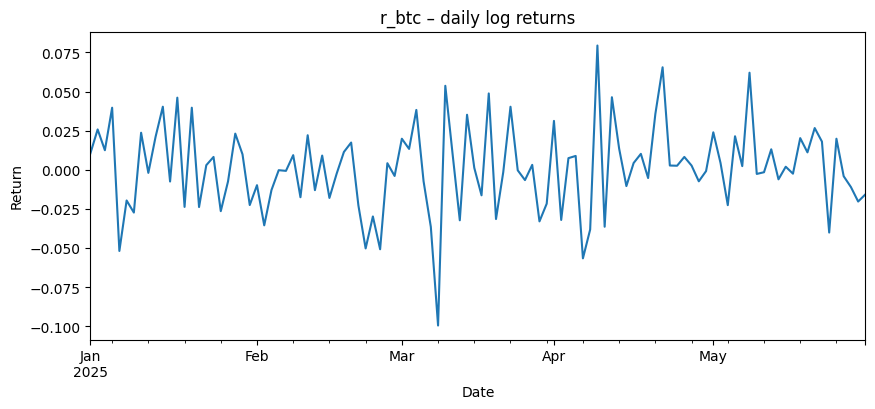

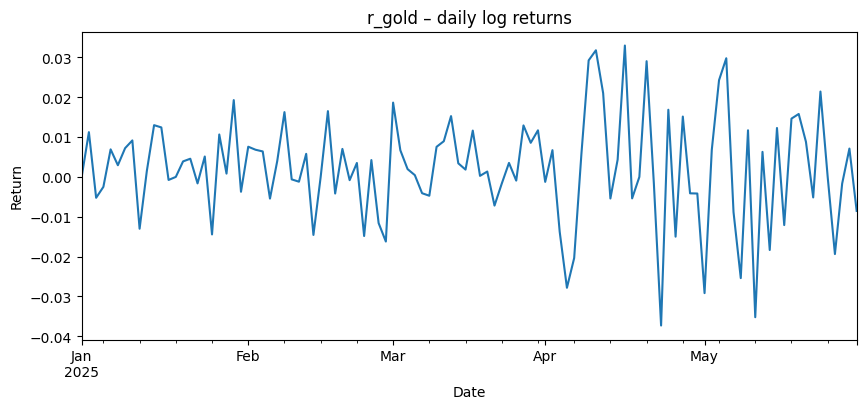

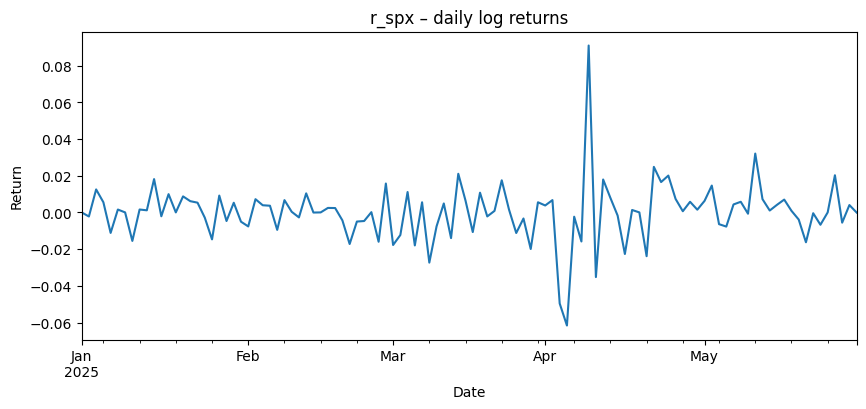

In [9]:

# Plot returns
for col in ["r_btc", "r_gold", "r_spx"]:
    ax = returns[col].plot(title=f"{col} – daily log returns")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    plt.show()


In [10]:

# Summary statistics
returns.describe().T


,count,mean,std,min,25%,50%,75%,max
r_btc,108.0000,0.0010,0.0280,-0.0994,-0.0166,0.0016,0.0176,0.0794
r_gold,108.0000,0.0021,0.0133,-0.0373,-0.0042,0.0024,0.0090,0.0330
r_spx,108.0000,0.0000,0.0161,-0.0616,-0.0052,0.0007,0.0063,0.0909
dln_eurusd,108.0000,-0.0008,0.0062,-0.0275,-0.0042,0.0003,0.0026,0.0145
dln_usdcny,108.0000,-0.0001,0.0026,-0.0113,-0.0003,0.0000,0.0007,0.0123
dln_oil,108.0000,-0.0015,0.0200,-0.0770,-0.0153,0.0000,0.0096,0.0454
dy10,108.0000,-0.0015,0.0600,-0.1410,-0.0430,0.0000,0.0340,0.1700
ei_creator,108.0000,-0.0664,0.2839,-1.0000,-0.1967,-0.0906,0.0041,1.0000
ei_community,108.0000,-0.2506,0.1169,-0.4400,-0.3186,-0.2758,-0.2149,0.2476
epi,108.0000,-0.3593,0.2604,-1.0000,-0.5354,-0.3318,-0.1608,0.0086


In [11]:
returns.head()

,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10,ei_creator,ei_community,epi,...,epi_Conspiracy and Historical Events,epi_Social and Cultural Aspects,epi_Power and Influence Dynamics,epi_Leadership and Governance,epi_Quality of Life and Standards,epi_Health and Social Welfare,epi_Labor and Workforce,epi_Environmental and Infrastructure,epi_Disaster and Resilience,epi_Miscellaneous and Other
2025-01-01,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-02,0.0258,0.0112,-0.0022,0.0052,0.0000,0.0195,0.0020,1.0000,0.0000,-1.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-03,0.0125,-0.0052,0.0125,0.0081,0.0001,0.0113,0.0210,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220,0.2727,0.0000,-0.3409,...,0.0000,-1.0000,0.0000,-1.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650,0.6000,-0.1972,-0.9966,...,-1.0000,-0.2829,0.0000,-0.4103,-0.7500,0.0455,-0.1562,0.0000,-0.4167,-0.0577


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
import datetime as dt

def epi_returns_plot(
    df: pd.DataFrame,
    *,
    filter_date: dt.date = dt.date(2025, 1, 13),
    event_windows=None,
    figsize=(20, 16),
    legend_ncol: int = 5,
    font_base: int = 18,
):
    if event_windows is None:
        event_windows = [
            ("2025-01-20", "2025-01-26"),
            ("2025-03-04", "2025-03-06"),
            ("2025-03-10", "2025-03-13"),
            ("2025-04-02", "2025-04-06"),
            ("2025-04-09", "2025-04-12"),
            ("2025-04-27", "2025-05-04"),
            ("2025-05-05", "2025-05-14"),
            ("2025-05-20", "2025-05-25"),
        ]

    left_series = [
        # Lowest priority: EI (thin + lighter + different dash patterns)
        ("ei_creator",   dict(ls=":", lw=2.0, label="Creator EI",   color="#34772E")),
        ("ei_community", dict(ls=":",  lw=2.0, label="Community EI", color="#344178")),

        # Mid priority: EPI signals (thicker + darker)
        ("epi",          dict(ls="--",  lw=2.0, label="EPI",              color="#AE2626")),
        ("epi_weighted", dict(ls="--", lw=2.0, label="Topic-Weighted EPI", color="#5B216D")),
    ]

    panels = [
        ("Bitcoin", "r_btc"),
        ("Gold",    "r_gold"),
        ("SPX",     "r_spx"),
    ]

    # Returns style: consistent across panels
    returns_style = dict(ls="-", lw=3.0, color="#252525", label="Asset Returns")

    # ---- data prep ----
    df1 = deepcopy(df)
    df1["date"] = pd.to_datetime(df1.index, errors="coerce")
    df1 = df1.dropna(subset=["date"])
    df1 = df1[df1["date"].dt.date >= filter_date].copy()
    df1 = df1.sort_values("date")

    # Ensure numeric (silent object dtypes can "plot" invisibly / oddly)
    for col in ["ei_creator", "ei_community", "epi", "epi_weighted", "r_btc", "r_gold", "r_spx"]:
        if col in df1.columns:
            df1[col] = pd.to_numeric(df1[col], errors="coerce")

    with plt.rc_context({
        "font.size": font_base,
        "axes.labelsize": font_base,
        "axes.titlesize": font_base + 2,
        "xtick.labelsize": font_base - 2,
        "ytick.labelsize": font_base - 2,
        "legend.fontsize": font_base - 2,
    }):
        fig, axs = plt.subplots(len(panels), 1, figsize=figsize, sharex=True)
        if len(panels) == 1:
            axs = [axs]
        right_axes = [ax.twinx() for ax in axs]

        # ✅ Transparent right axis, but drawn ABOVE left axis so returns are visible
        for ax_l, ax_r in zip(axs, right_axes):
            ax_r.patch.set_visible(False)
            ax_r.set_zorder(ax_l.get_zorder() + 1)

        def shade(ax_l):
            for s, e in event_windows:
                sdt, edt = pd.to_datetime(s), pd.to_datetime(e)
                ax_l.axvspan(sdt, edt, color="0.88", alpha=0.7, zorder=0)

        def polish(ax_l, ax_r, panel_title: str):
            ax_l.set_ylabel("EI / EPI", fontweight="bold")
            ax_r.set_ylabel(f"{panel_title} Returns", fontweight="bold")

            ax_l.grid(True, axis="y", alpha=0.25)
            ax_l.set_axisbelow(True)

            ax_l.spines["top"].set_visible(False)
            ax_r.spines["top"].set_visible(False)

            ax_l.set_title(panel_title, loc="left", pad=6)

        for (ax_l, ax_r), (title, r_col) in zip(zip(axs, right_axes), panels):
            shade(ax_l)

            # Left axis series
            for col, sty in left_series:
                ax_l.plot(df1["date"], df1[col], zorder=3, **sty)

            # Right axis returns
            ax_r.plot(df1["date"], df1[r_col], zorder=4, **returns_style)

            polish(ax_l, ax_r, title)

        # Weekly x ticks
        week_starts = df1["date"].dt.to_period("W").drop_duplicates().dt.start_time
        axs[-1].set_xticks(week_starts)
        axs[-1].set_xticklabels(week_starts.dt.strftime("%d-%b"), rotation=45, ha="right")

        # Legend from all axes
        handles, labels = [], []
        for ax in axs:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h); labels.extend(l)
        for ax in right_axes:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h); labels.extend(l)

        seen, uniq_h, uniq_l = set(), [], []
        for h, l in zip(handles, labels):
            if l and (l not in seen):
                uniq_h.append(h); uniq_l.append(l); seen.add(l)

        fig.legend(
            uniq_h, uniq_l,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.04),
            ncol=legend_ncol,
            frameon=False,
        )

        fig.tight_layout(rect=[0, 0.06, 1, 1])
        plt.show()


In [13]:
# 7 day moving average of all columns
returns_ma7 = returns.rolling(window=7, min_periods=1).mean()
returns.head()

,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10,ei_creator,ei_community,epi,...,epi_Conspiracy and Historical Events,epi_Social and Cultural Aspects,epi_Power and Influence Dynamics,epi_Leadership and Governance,epi_Quality of Life and Standards,epi_Health and Social Welfare,epi_Labor and Workforce,epi_Environmental and Infrastructure,epi_Disaster and Resilience,epi_Miscellaneous and Other
2025-01-01,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-02,0.0258,0.0112,-0.0022,0.0052,0.0000,0.0195,0.0020,1.0000,0.0000,-1.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-03,0.0125,-0.0052,0.0125,0.0081,0.0001,0.0113,0.0210,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220,0.2727,0.0000,-0.3409,...,0.0000,-1.0000,0.0000,-1.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650,0.6000,-0.1972,-0.9966,...,-1.0000,-0.2829,0.0000,-0.4103,-0.7500,0.0455,-0.1562,0.0000,-0.4167,-0.0577


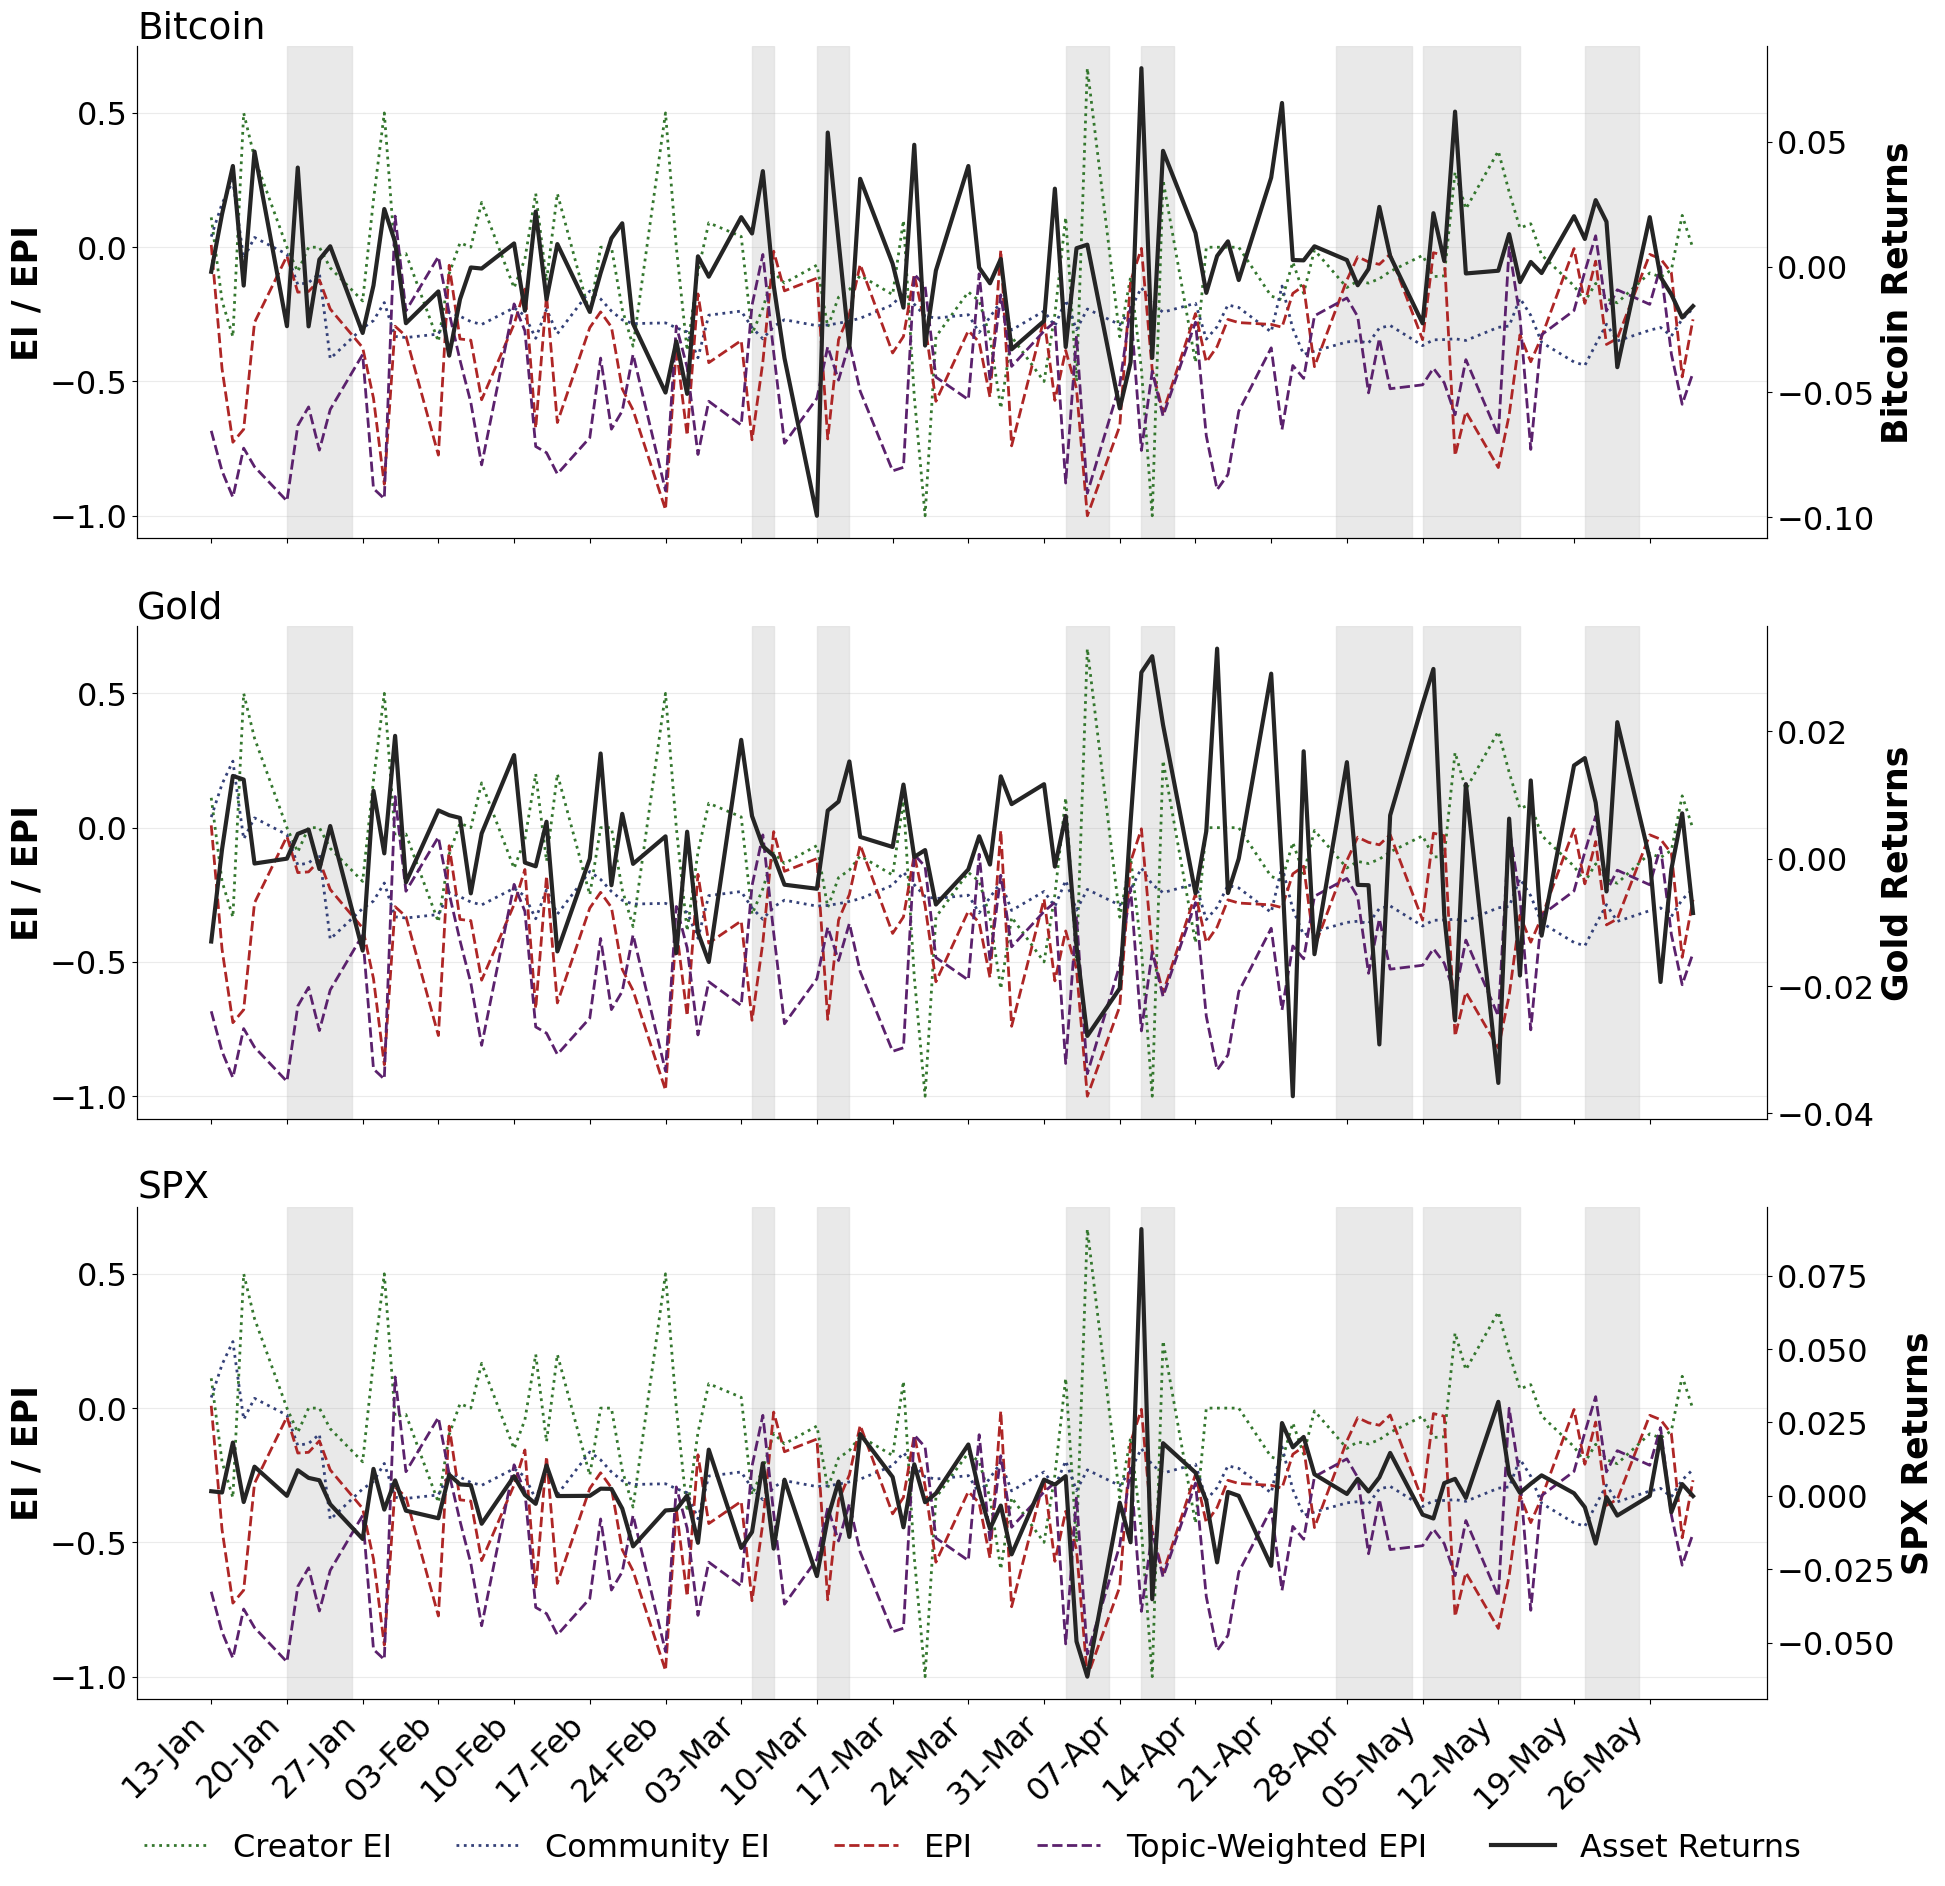

In [51]:
epi_returns_plot(returns, figsize=(20, 20), font_base=25)

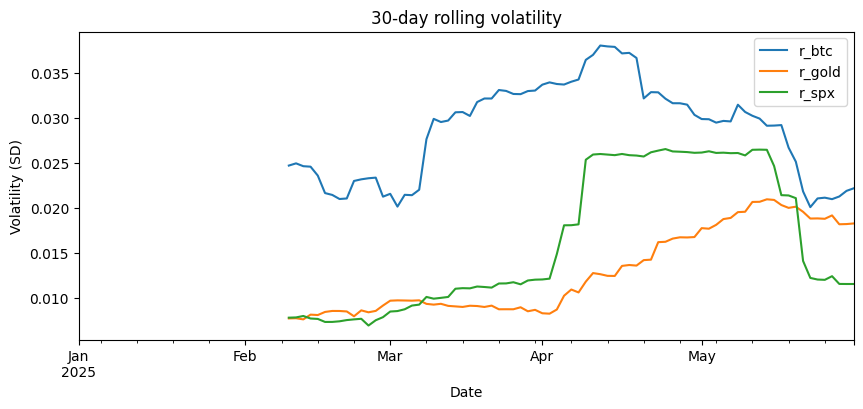

In [15]:

# Rolling 30-day volatility for selected assets
rolling_window = 30
vol = returns[["r_btc", "r_gold", "r_spx"]].rolling(rolling_window).std()

ax = vol.plot(title=f"{rolling_window}-day rolling volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (SD)")
plt.show()


In [16]:

# Correlation matrix
corr = returns[["r_btc", "r_gold", "r_spx"]].corr()
corr


,r_btc,r_gold,r_spx
r_btc,1.0000,0.0504,0.3796
r_gold,0.0504,1.0000,-0.0177
r_spx,0.3796,-0.0177,1.0000



## 6. Stationarity checks (ADF tests)


In [17]:

def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test for {name}")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print("  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-" * 40)

for col in returns.columns:
    adf_test(returns[col], name=col)


ADF Test for r_btc
  Test statistic: -11.3955
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for r_gold
  Test statistic: -10.2024
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for r_spx
  Test statistic: -11.3953
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_eurusd
  Test statistic: -10.1000
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_usdcny
  Test statistic: -10.4155
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_oil
  Test statistic: -5.0250
  p-value:        0.0000
  Critical values


## 7. Baseline ARX models (no emotions)

We estimate an ARX model for each asset:

\[ r_{i,t} = \alpha + \sum_{k=1}^{p} \phi_k r_{i,t-k} + \beta' x_t + \varepsilon_t, \]

where \(x_t\) are the macro control variables.


In [18]:
# Prepare a working copy
# Build lags up to max_p to allow testing alternative AR orders
max_p = 3
p = 1  # baseline order used below

data = returns.copy()

# Create lags for each asset
for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_p + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

# Control variable names
control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]

data_arx = data.dropna()
data_arx.head()


,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10,ei_creator,ei_community,epi,...,epi_Miscellaneous and Other,r_btc_l1,r_btc_l2,r_btc_l3,r_gold_l1,r_gold_l2,r_gold_l3,r_spx_l1,r_spx_l2,r_spx_l3
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220,0.2727,0.0000,-0.3409,...,0.0000,0.0125,0.0258,0.0105,-0.0052,0.0112,0.0000,0.0125,-0.0022,0.0000
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650,0.6000,-0.1972,-0.9966,...,-0.0577,0.0397,0.0125,0.0258,-0.0025,-0.0052,0.0112,0.0055,0.0125,-0.0022
2025-01-08,-0.0196,0.0029,0.0016,0.0039,0.0006,-0.0126,0.0100,0.0000,-0.2396,-0.2995,...,-0.0355,-0.0518,0.0397,0.0125,0.0069,-0.0025,-0.0052,-0.0112,0.0055,0.0125
2025-01-09,-0.0273,0.0072,0.0000,0.0030,0.0007,0.0081,0.0000,0.0000,-0.3575,-0.4469,...,-0.1786,-0.0196,-0.0518,0.0397,0.0029,0.0069,-0.0025,0.0016,-0.0112,0.0055
2025-01-10,0.0237,0.0092,-0.0155,0.0017,0.0001,0.0352,0.0830,0.3333,-0.3713,-0.8808,...,0.0000,-0.0273,-0.0196,-0.0518,0.0072,0.0029,0.0069,0.0000,0.0016,-0.0112


In [19]:

def fit_arx(data, asset, p=1, control_cols=None):
    if control_cols is None:
        control_cols = []

    cols_lag = [f"{asset}_l{lag}" for lag in range(1, p + 1)]
    cols_exog = cols_lag + control_cols

    df = data.dropna(subset=[asset] + cols_exog)
    y = df[asset]
    X = sm.add_constant(df[cols_exog])

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":5})
    return model

arx_results = {}
for asset in ["r_btc", "r_gold", "r_spx"]:
    model = fit_arx(data, asset, p=p, control_cols=control_cols)
    arx_results[asset] = model
    print(f"\n=== ARX results for {asset} ===")
    print(model.summary().tables[1])



=== ARX results for r_btc ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.002      0.336      0.737      -0.004       0.005
r_btc_l1      -0.0717      0.090     -0.795      0.427      -0.249       0.105
dln_eurusd    -0.9205      0.458     -2.010      0.044      -1.818      -0.023
dln_usdcny    -0.0249      0.753     -0.033      0.974      -1.500       1.450
dln_oil        0.2915      0.149      1.956      0.050      -0.001       0.584
dy10           0.0779      0.065      1.196      0.232      -0.050       0.206

=== ARX results for r_gold ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      2.256      0.024       0.000       0.004
r_gold_l1     -0.0445      0.133     -0.334      0.738      -0.305  

In [20]:
# Explore ARX lag lengths (p = 1..3)
lag_options = [1, 2, 3]
arx_metrics = []

for p_opt in lag_options:
    for asset in ["r_btc", "r_gold", "r_spx"]:
        model = fit_arx(data, asset, p=p_opt, control_cols=control_cols)
        arx_metrics.append({
            "asset": asset,
            "p": p_opt,
            "aic": model.aic,
            "bic": model.bic,
            "r2": model.rsquared,
            "nobs": model.nobs,
        })

arx_metrics_df = pd.DataFrame(arx_metrics)
print("ARX info criteria (lower is better):")
display(arx_metrics_df.pivot(index="asset", columns="p", values="bic").round(3))
display(arx_metrics_df.pivot(index="asset", columns="p", values="aic").round(3))
print("ARX R^2 by lag order:")
display(arx_metrics_df.pivot(index="asset", columns="p", values="r2").round(4))


ARX info criteria (lower is better):


p,1,2,3
asset,,,
r_btc,-447.8020,-438.6700,-429.8210
r_gold,-599.0270,-588.1050,-579.3050
r_spx,-582.6300,-571.9250,-561.1310


p,1,2,3
asset,,,
r_btc,-463.8390,-457.3140,-451.0530
r_gold,-615.0640,-606.7490,-600.5360
r_spx,-598.6670,-590.5690,-582.3620


ARX R^2 by lag order:


p,1,2,3
asset,,,
r_btc,0.1234,0.1244,0.1327
r_gold,0.0531,0.0537,0.0746
r_spx,0.2462,0.2503,0.2496


In [21]:
# ARX lag selection with rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

sel_records = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols
        df_fit = data.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = dir_acc = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5
            # Directional accuracy: % of times forecast sign matches actual sign
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100

        sel_records.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "dir_acc": dir_acc,
            "nobs": len(df_fit),
        })

sel_df_arx = pd.DataFrame(sel_records)
print("ARX lag grid (lower is better for BIC/AIC/MAE/RMSE, higher is better for Dir Acc):")
print(sel_df_arx.pivot(index="asset", columns="p", values="bic").round(3))
print(sel_df_arx.pivot(index="asset", columns="p", values="aic").round(3))
print("MAE (rolling 1-step):")
print(sel_df_arx.pivot(index="asset", columns="p", values="mae").round(5))
print("RMSE (rolling 1-step):")
print(sel_df_arx.pivot(index="asset", columns="p", values="rmse").round(5))
print("Directional Accuracy (%, higher is better):")
print(sel_df_arx.pivot(index="asset", columns="p", values="dir_acc").round(2))

best_bic_arx = sel_df_arx.sort_values("bic").groupby("asset").first()
best_rmse_arx = sel_df_arx.sort_values("rmse").groupby("asset").first()
print("Best by BIC per asset:")
print(best_bic_arx[["bic", "p"]])
print("Best by RMSE per asset:")
print(best_rmse_arx[["rmse", "p"]])


ARX lag grid (lower is better for BIC/AIC/MAE/RMSE, higher is better for Dir Acc):
p              1         2         3
asset                               
r_btc  -447.8020 -438.6700 -429.8210
r_gold -599.0270 -588.1050 -579.3050
r_spx  -582.6300 -571.9250 -561.1310
p              1         2         3
asset                               
r_btc  -463.8390 -457.3140 -451.0530
r_gold -615.0640 -606.7490 -600.5360
r_spx  -598.6670 -590.5690 -582.3620
MAE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0201 0.0207 0.0203
r_gold 0.0150 0.0155 0.0155
r_spx  0.0141 0.0143 0.0151
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0266 0.0271 0.0272
r_gold 0.0184 0.0188 0.0191
r_spx  0.0202 0.0204 0.0218
Directional Accuracy (%, higher is better):
p            1       2       3
asset                         
r_btc  51.0600 50.0000 48.8900
r_gold 42.5500 43.4800 48.8900
r_spx  46.8100 52.1700 51.1100
Best by BIC per asset:


ARX r_btc: p=1, MAE=0.02010, RMSE=0.02658


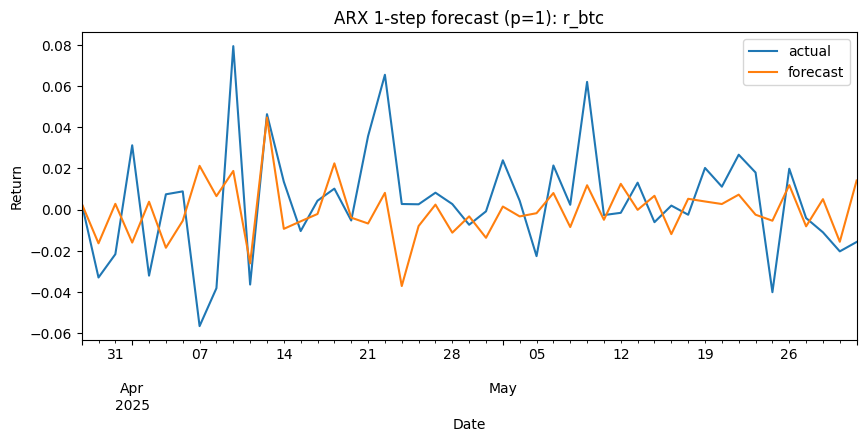

ARX r_gold: p=1, MAE=0.01504, RMSE=0.01837


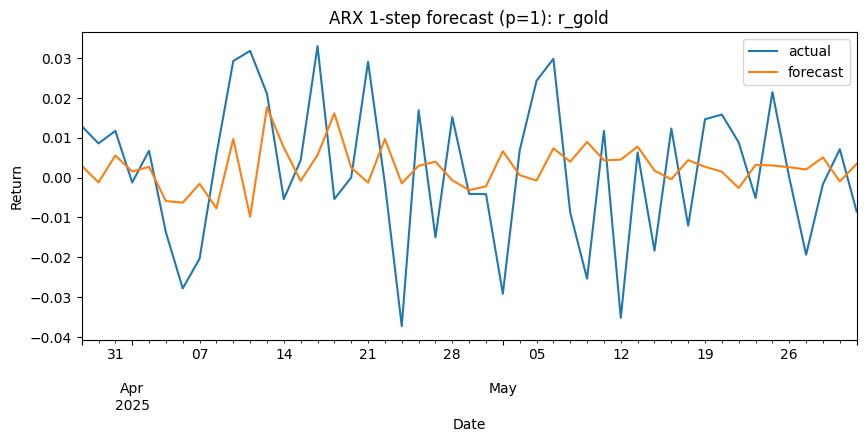

ARX r_spx: p=1, MAE=0.01407, RMSE=0.02019


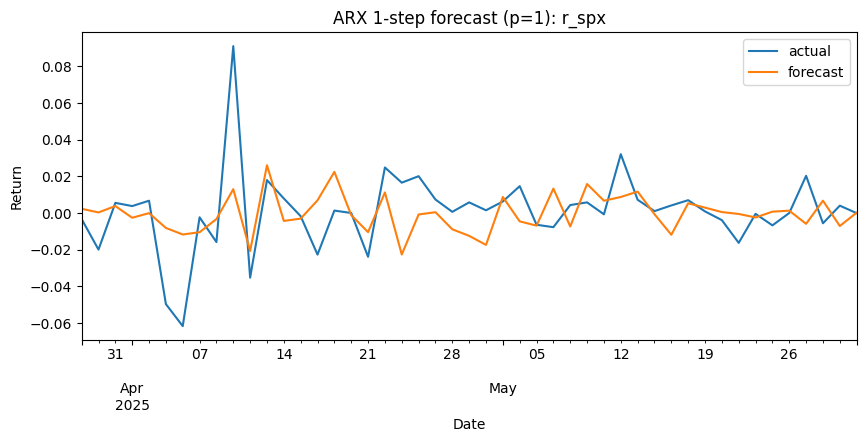

In [22]:
# Plot ARX forecasts using best lag (by RMSE)
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

if 'best_rmse_arx' not in globals():
    raise RuntimeError("Run the ARX selection cell first.")

for asset in assets:
    p_opt = int(best_rmse_arx.loc[asset, 'p'])
    cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
    cols_exog = cols_lag + control_cols
    df_fit = data.dropna(subset=[asset] + cols_exog)
    if len(df_fit) <= min_train:
        print(f"Not enough observations for {asset} with p={p_opt}")
        continue

    y_all = df_fit[asset]
    preds, dates = [], []
    for i in range(min_train, len(df_fit)):
        y_train = y_all.iloc[:i]
        X_train = sm.add_constant(df_fit[cols_exog].iloc[:i], has_constant="add")
        m = sm.OLS(y_train, X_train).fit()
        x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
        pred = m.predict(x_next).iloc[0]
        preds.append(pred)
        dates.append(df_fit.index[i])

    fc_series = pd.Series(preds, index=dates, name="forecast")
    actual_series = y_all.loc[fc_series.index]
    mae = (fc_series - actual_series).abs().mean()
    rmse = ((fc_series - actual_series) ** 2).mean() ** 0.5
    print(f"ARX {asset}: p={p_opt}, MAE={mae:.5f}, RMSE={rmse:.5f}")

    ax = actual_series.plot(label="actual", title=f"ARX 1-step forecast (p={p_opt}): {asset}")
    fc_series.plot(ax=ax, label="forecast")
    ax.legend()
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    plt.show()


## 7b. ARX models with EPI

We augment the baseline ARX model by adding the Emotion Polarity Index (EPI) as an additional exogenous regressor:

\[ r_{i,t} = \alpha + \sum_{k=1}^{p} \phi_k r_{i,t-k} + \beta' x_t + \gamma \cdot \text{EPI}_t + \varepsilon_t \]

In [23]:
# ARX with EPI - lag selection using rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns now include EPI
control_cols_epi = control_cols + ["epi"]

sel_records_epi = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_epi
        df_fit = data.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = dir_acc = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5
            # Directional accuracy: % of times forecast sign matches actual sign
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100

        sel_records_epi.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "dir_acc": dir_acc,
            "nobs": len(df_fit),
            "model": "ARX + EPI"
        })

sel_df_arx_epi = pd.DataFrame(sel_records_epi)
print("ARX + EPI lag grid (lower is better for BIC/MAE/RMSE, higher for Dir Acc):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="bic").round(3))
print("MAE (rolling 1-step):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="mae").round(5))
print("RMSE (rolling 1-step):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="rmse").round(5))
print("Directional Accuracy (%, higher is better):")
print(sel_df_arx_epi.pivot(index="asset", columns="p", values="dir_acc").round(2))

best_bic_arx_epi = sel_df_arx_epi.sort_values("bic").groupby("asset").first()
best_rmse_arx_epi = sel_df_arx_epi.sort_values("rmse").groupby("asset").first()
print("\nBest by BIC per asset:")
print(best_bic_arx_epi[["bic", "p"]])
print("Best by RMSE per asset:")
print(best_rmse_arx_epi[["rmse", "p"]])

ARX + EPI lag grid (lower is better for BIC/MAE/RMSE, higher for Dir Acc):
p              1         2         3
asset                               
r_btc  -443.1740 -434.2260 -425.2530
r_gold -594.7150 -584.0460 -575.3150
r_spx  -587.4410 -576.4000 -565.5380
MAE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0200 0.0205 0.0202
r_gold 0.0153 0.0157 0.0157
r_spx  0.0134 0.0136 0.0146
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0268 0.0272 0.0273
r_gold 0.0186 0.0190 0.0192
r_spx  0.0193 0.0196 0.0209
Directional Accuracy (%, higher is better):
p            1       2       3
asset                         
r_btc  51.0600 47.8300 48.8900
r_gold 42.5500 45.6500 51.1100
r_spx  48.9400 50.0000 48.8900

Best by BIC per asset:
             bic  p
asset              
r_btc  -443.1742  1
r_gold -594.7154  1
r_spx  -587.4414  1
Best by RMSE per asset:
         rmse  p
asset           
r_btc  0.0268  1
r_gold 0.0186  1


## 7c. ARX models with Topic-Weighted EPI

We augment the ARX model using the topic-weighted EPI (`epi_weighted`) which accounts for the relative importance of different topics:

\[ r_{i,t} = \alpha + \sum_{k=1}^{p} \phi_k r_{i,t-k} + \beta' x_t + \gamma \cdot \text{EPI}^{weighted}_t + \varepsilon_t \]

In [24]:
# ARX with Topic-Weighted EPI - lag selection using rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns now include topic-weighted EPI
control_cols_epi_weighted = control_cols + ["epi_weighted"]

sel_records_epi_weighted = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_epi_weighted
        df_fit = data.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = dir_acc = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5
            # Directional accuracy: % of times forecast sign matches actual sign
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100

        sel_records_epi_weighted.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "dir_acc": dir_acc,
            "nobs": len(df_fit),
            "model": "ARX + EPI_weighted"
        })

sel_df_arx_epi_weighted = pd.DataFrame(sel_records_epi_weighted)
print("ARX + Topic-Weighted EPI lag grid (lower is better for BIC/MAE/RMSE, higher for Dir Acc):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="bic").round(3))
print("MAE (rolling 1-step):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="mae").round(5))
print("RMSE (rolling 1-step):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="rmse").round(5))
print("Directional Accuracy (%, higher is better):")
print(sel_df_arx_epi_weighted.pivot(index="asset", columns="p", values="dir_acc").round(2))

best_bic_arx_epi_weighted = sel_df_arx_epi_weighted.sort_values("bic").groupby("asset").first()
best_rmse_arx_epi_weighted = sel_df_arx_epi_weighted.sort_values("rmse").groupby("asset").first()
print("\nBest by BIC per asset:")
print(best_bic_arx_epi_weighted[["bic", "p"]])
print("Best by RMSE per asset:")
print(best_rmse_arx_epi_weighted[["rmse", "p"]])

ARX + Topic-Weighted EPI lag grid (lower is better for BIC/MAE/RMSE, higher for Dir Acc):
p              1         2         3
asset                               
r_btc  -443.1310 -434.0570 -425.1720
r_gold -594.4490 -583.5860 -574.8090
r_spx  -577.9780 -567.2630 -556.4780
MAE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0202 0.0207 0.0204
r_gold 0.0152 0.0156 0.0157
r_spx  0.0142 0.0145 0.0153
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0267 0.0272 0.0272
r_gold 0.0185 0.0190 0.0192
r_spx  0.0204 0.0206 0.0220
Directional Accuracy (%, higher is better):
p            1       2       3
asset                         
r_btc  51.0600 50.0000 48.8900
r_gold 42.5500 41.3000 46.6700
r_spx  48.9400 54.3500 51.1100

Best by BIC per asset:
             bic  p
asset              
r_btc  -443.1310  1
r_gold -594.4491  1
r_spx  -577.9776  1
Best by RMSE per asset:
         rmse  p
asset           
r_btc  0.0267  1
r_


## 8. Baseline VAR model (no emotions)

We estimate a VAR model on the three return series, optionally with exogenous macro controls.


In [25]:
# VAR with exogenous controls
Y = returns[["r_btc", "r_gold", "r_spx"]]
X_exog = returns[control_cols]

# Align and drop missing rows
var_data = pd.concat([Y, X_exog], axis=1).dropna()
Y_var = var_data[["r_btc", "r_gold", "r_spx"]]
X_var = var_data[control_cols]

# Select lag order (can inspect select_order results)
var_model = VAR(Y_var, exog=X_var)
lag_order_results = var_model.select_order(maxlags=10)
print(lag_order_results.summary())


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -24.31*     -23.91*  2.773e-11*     -24.15*
1       -24.20      -23.57   3.094e-11      -23.94
2       -24.12      -23.25   3.345e-11      -23.77
3       -24.12      -23.01   3.365e-11      -23.67
4       -24.09      -22.74   3.502e-11      -23.54
5       -24.04      -22.46   3.691e-11      -23.40
6       -23.97      -22.15   3.994e-11      -23.23
7       -23.85      -21.79   4.571e-11      -23.02
8       -23.73      -21.43   5.228e-11      -22.80
9       -23.83      -21.29   4.844e-11      -22.80
10      -23.86      -21.09   4.777e-11      -22.74
--------------------------------------------------


In [26]:
# Fit VAR with chosen lag order (e.g. 1)
p_var = 1
var_model = VAR(Y_var, exog=X_var)
var_results = var_model.fit(p_var, trend="c")

print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 31, Dec, 2025
Time:                     22:32:03
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.6713
Nobs:                     107.000    HQIC:                  -24.0277
Log likelihood:           867.007    FPE:                2.88207e-11
AIC:                     -24.2708    Det(Omega_mle):     2.32146e-11
--------------------------------------------------------------------
Results for equation r_btc
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.000409         0.002670            0.153           0.878
dln_eurusd        -0.693533         0.495833           -1.399           0.162
dln_usdcny        -0.105881         1.101340           -0.096           

In [27]:
# Compare VAR lag lengths with exogenous controls (p = 1..3)
var_compare = []
var_results_by_p = {}
for p_opt in [1, 2, 3]:
    res = VAR(Y_var, exog=X_var).fit(p_opt, trend="c")
    var_results_by_p[p_opt] = res
    var_compare.append({
        "p": p_opt,
        "aic": res.aic,
        "bic": res.bic,
        "hqic": res.hqic,
        "fpe": res.fpe,
    })

var_compare_df = pd.DataFrame(var_compare).set_index("p")
print("VAR info criteria (lower is better):")
print(var_compare_df.round(4))

from statsmodels.stats.stattools import durbin_watson
for p_opt, res in var_results_by_p.items():
    dw = durbin_watson(res.resid)
    print(f"Durbin-Watson (p={p_opt}): BTC {dw[0]:.2f}, Gold {dw[1]:.2f}, SPX {dw[2]:.2f}")


VAR info criteria (lower is better):
       aic      bic     hqic    fpe
p                                  
1 -24.2708 -23.6713 -24.0277 0.0000
2 -24.1795 -23.3504 -23.8435 0.0000
3 -24.1566 -23.0950 -23.7264 0.0000
Durbin-Watson (p=1): BTC 2.04, Gold 1.96, SPX 2.06
Durbin-Watson (p=2): BTC 2.02, Gold 1.87, SPX 2.05
Durbin-Watson (p=3): BTC 2.00, Gold 1.98, SPX 2.18


### Predictions

In [28]:
# Model selection over lag choices using rolling 1-step forecasts (VAR)
# Loops over p in p_grid, reports BIC/AIC and rolling MAE/RMSE, and picks the best by RMSE
p_grid = [1, 2, 3]
min_train = 60

try:
    Y_base = Y_var.copy()
    X_base = X_var.copy()
except NameError:
    raise RuntimeError("Run the VAR setup cells before this selection cell.")

sel_records_var = []
for p_opt in p_grid:
    res = VAR(Y_base, exog=X_base).fit(p_opt, trend="c")
    if len(Y_base) <= min_train + p_opt:
        mae = rmse = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
        dir_acc = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
    else:
        preds = []
        dates = Y_base.index[min_train:]
        for i, dt in enumerate(dates):
            train_end = min_train + i
            y_train = Y_base.iloc[:train_end]
            x_train = X_base.iloc[:train_end]
            model = VAR(y_train, exog=x_train).fit(p_opt, trend="c")
            y_last = y_train.values[-model.k_ar:]
            x_future = X_base.iloc[train_end:train_end+1].values
            pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
            preds.append({"date": dt, "pred_r_btc": pred[0], "pred_r_gold": pred[1], "pred_r_spx": pred[2]})
        fc_df = pd.DataFrame(preds).set_index("date")
        actual = Y_base.loc[fc_df.index]
        diff = fc_df.to_numpy() - actual.to_numpy()
        mae_vec = np.abs(diff).mean(axis=0)
        rmse_vec = np.sqrt((diff ** 2).mean(axis=0))
        mae = {"r_btc": mae_vec[0], "r_gold": mae_vec[1], "r_spx": mae_vec[2], "avg": mae_vec.mean()}
        rmse = {"r_btc": rmse_vec[0], "r_gold": rmse_vec[1], "r_spx": rmse_vec[2], "avg": rmse_vec.mean()}
        # Directional accuracy: % of times forecast sign matches actual sign
        dir_btc = (np.sign(fc_df["pred_r_btc"]) == np.sign(actual["r_btc"])).mean() * 100
        dir_gold = (np.sign(fc_df["pred_r_gold"]) == np.sign(actual["r_gold"])).mean() * 100
        dir_spx = (np.sign(fc_df["pred_r_spx"]) == np.sign(actual["r_spx"])).mean() * 100
        dir_acc = {"r_btc": dir_btc, "r_gold": dir_gold, "r_spx": dir_spx, "avg": np.mean([dir_btc, dir_gold, dir_spx])}

    sel_records_var.append({
        "p": p_opt,
        "bic": res.bic,
        "aic": res.aic,
        "mae_btc": mae["r_btc"], "mae_gold": mae["r_gold"], "mae_spx": mae["r_spx"], "mae_avg": mae["avg"],
        "rmse_btc": rmse["r_btc"], "rmse_gold": rmse["r_gold"], "rmse_spx": rmse["r_spx"], "rmse_avg": rmse["avg"],
        "dir_btc": dir_acc["r_btc"], "dir_gold": dir_acc["r_gold"], "dir_spx": dir_acc["r_spx"], "dir_avg": dir_acc["avg"],
    })

sel_df_var = pd.DataFrame(sel_records_var).set_index("p")
print("Lag grid results (lower is better for BIC/AIC/MAE/RMSE, higher for Dir Acc):")
print(sel_df_var[["bic", "aic", "mae_avg", "rmse_avg", "dir_avg"]].round(4))

best_bic_p_var = sel_df_var["bic"].idxmin()
best_rmse_p_var = sel_df_var["rmse_avg"].idxmin()
print(f"Best by BIC: p={best_bic_p_var}")
print(f"Best by avg RMSE: p={best_rmse_p_var}")


Lag grid results (lower is better for BIC/AIC/MAE/RMSE, higher for Dir Acc):
       bic      aic  mae_avg  rmse_avg  dir_avg
p                                              
1 -23.6713 -24.2708   0.0170    0.0221  49.3056
2 -23.3504 -24.1795   0.0169    0.0223  54.8611
3 -23.0950 -24.1566   0.0176    0.0230  50.0000
Best by BIC: p=1
Best by avg RMSE: p=1


Rolling 1-step forecast metrics (VAR p=1):
               mae   rmse
pred_r_btc  0.0219 0.0219
pred_r_gold 0.0145 0.0145
pred_r_spx  0.0147 0.0147


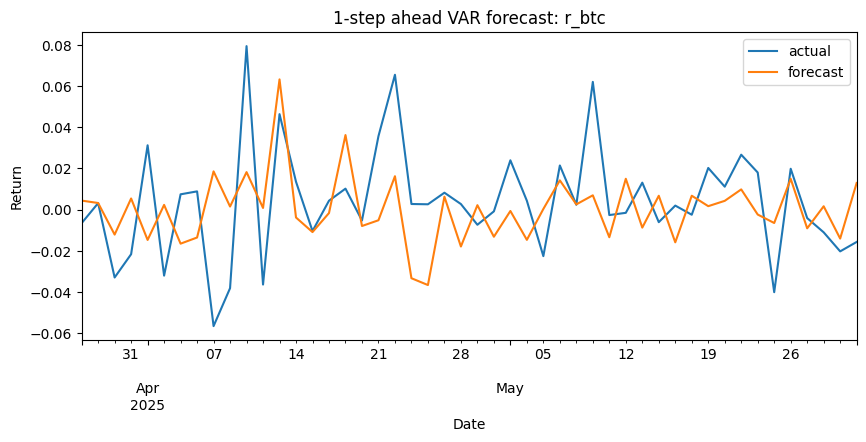

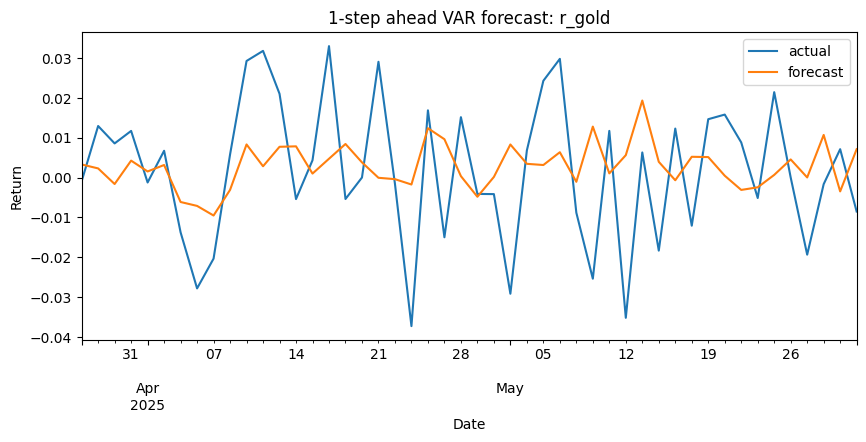

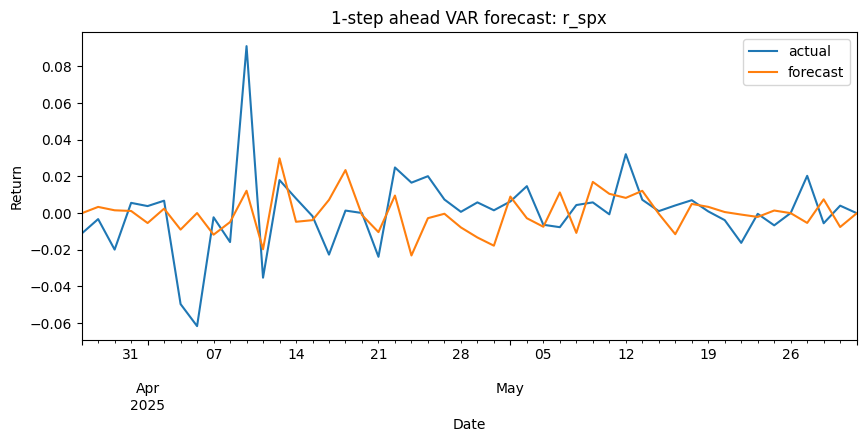

In [29]:
# Rolling one-step-ahead forecasts (VAR with exogenous controls)
# Uses expanding window, 1-step ahead, p=1 by default
p_forecast = best_rmse_p_var if "best_rmse_p_var" in globals() else 2
min_train = 60  # need enough history for stable estimates

# Reuse prepared Y_var and X_var; ensure they exist
try:
    Y_base = Y_var.copy()
    X_base = X_var.copy()
except NameError:
    raise RuntimeError("Ensure VAR setup cells have been run before this forecast cell.")

if len(Y_base) <= min_train + p_forecast:
    print("Not enough observations for rolling forecasts")
else:
    records = []
    dates = Y_base.index[min_train:]
    for i, dt in enumerate(dates):
        train_end = min_train + i
        y_train = Y_base.iloc[:train_end]
        x_train = X_base.iloc[:train_end]
        model = VAR(y_train, exog=x_train).fit(p_forecast, trend="c")
        y_last = y_train.values[-model.k_ar:]
        x_future = X_base.iloc[train_end:train_end+1].values
        pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
        records.append({
            "date": dt,
            "pred_r_btc": pred[0],
            "pred_r_gold": pred[1],
            "pred_r_spx": pred[2],
        })
    fc_df = pd.DataFrame(records).set_index("date")
    actual = Y_base.loc[fc_df.index]
    eval_df = pd.DataFrame({
        "mae": (fc_df.sub(actual.values)).abs().mean(),
        "rmse": np.sqrt((fc_df.sub(actual.values))**2).mean(),
    })
    print(f"Rolling 1-step forecast metrics (VAR p={p_forecast}):")
    print(eval_df)

    # Plot actual vs predicted
    for col, pred_col in [("r_btc", "pred_r_btc"), ("r_gold", "pred_r_gold"), ("r_spx", "pred_r_spx")]:
        ax = actual[col].plot(label="actual", title=f"1-step ahead VAR forecast: {col}")
        fc_df[pred_col].plot(ax=ax, label="forecast")
        ax.legend()
        ax.set_xlabel("Date")
        ax.set_ylabel("Return")
        plt.show()


## 8b. VAR model with EPI

We extend the baseline VAR by adding the EPI as an additional exogenous variable alongside the macro controls.

In [30]:
# VAR with EPI as exogenous variable
Y_var_epi = returns[["r_btc", "r_gold", "r_spx"]]
X_var_epi = returns[control_cols + ["epi"]]

# Align and drop missing rows
var_data_epi = pd.concat([Y_var_epi, X_var_epi], axis=1).dropna()
Y_var_epi = var_data_epi[["r_btc", "r_gold", "r_spx"]]
X_var_epi = var_data_epi[control_cols + ["epi"]]

# Model selection with rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60

sel_records_var_epi = []
for p_opt in p_grid:
    res = VAR(Y_var_epi, exog=X_var_epi).fit(p_opt, trend="c")
    if len(Y_var_epi) <= min_train + p_opt:
        mae = rmse = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
        dir_acc = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
    else:
        preds = []
        dates = Y_var_epi.index[min_train:]
        for i, dt in enumerate(dates):
            train_end = min_train + i
            y_train = Y_var_epi.iloc[:train_end]
            x_train = X_var_epi.iloc[:train_end]
            model = VAR(y_train, exog=x_train).fit(p_opt, trend="c")
            y_last = y_train.values[-model.k_ar:]
            x_future = X_var_epi.iloc[train_end:train_end+1].values
            pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
            preds.append({"date": dt, "pred_r_btc": pred[0], "pred_r_gold": pred[1], "pred_r_spx": pred[2]})
        fc_df = pd.DataFrame(preds).set_index("date")
        actual = Y_var_epi.loc[fc_df.index]
        diff = fc_df.to_numpy() - actual.to_numpy()
        mae_vec = np.abs(diff).mean(axis=0)
        rmse_vec = np.sqrt((diff ** 2).mean(axis=0))
        mae = {"r_btc": mae_vec[0], "r_gold": mae_vec[1], "r_spx": mae_vec[2], "avg": mae_vec.mean()}
        rmse = {"r_btc": rmse_vec[0], "r_gold": rmse_vec[1], "r_spx": rmse_vec[2], "avg": rmse_vec.mean()}
        # Directional accuracy
        dir_btc = (np.sign(fc_df["pred_r_btc"]) == np.sign(actual["r_btc"])).mean() * 100
        dir_gold = (np.sign(fc_df["pred_r_gold"]) == np.sign(actual["r_gold"])).mean() * 100
        dir_spx = (np.sign(fc_df["pred_r_spx"]) == np.sign(actual["r_spx"])).mean() * 100
        dir_acc = {"r_btc": dir_btc, "r_gold": dir_gold, "r_spx": dir_spx, "avg": np.mean([dir_btc, dir_gold, dir_spx])}

    sel_records_var_epi.append({
        "p": p_opt,
        "bic": res.bic,
        "aic": res.aic,
        "mae_btc": mae["r_btc"], "mae_gold": mae["r_gold"], "mae_spx": mae["r_spx"], "mae_avg": mae["avg"],
        "rmse_btc": rmse["r_btc"], "rmse_gold": rmse["r_gold"], "rmse_spx": rmse["r_spx"], "rmse_avg": rmse["avg"],
        "dir_btc": dir_acc["r_btc"], "dir_gold": dir_acc["r_gold"], "dir_spx": dir_acc["r_spx"], "dir_avg": dir_acc["avg"],
        "model": "VAR + EPI"
    })

sel_df_var_epi = pd.DataFrame(sel_records_var_epi).set_index("p")
print("VAR + EPI lag grid results (lower is better for BIC/MAE/RMSE, higher for Dir Acc):")
print(sel_df_var_epi[["bic", "aic", "mae_avg", "rmse_avg", "dir_avg"]].round(4))

best_bic_p_var_epi = sel_df_var_epi["bic"].idxmin()
best_rmse_p_var_epi = sel_df_var_epi["rmse_avg"].idxmin()
print(f"\nBest by BIC: p={best_bic_p_var_epi}")
print(f"Best by avg RMSE: p={best_rmse_p_var_epi}")

VAR + EPI lag grid results (lower is better for BIC/MAE/RMSE, higher for Dir Acc):
       bic      aic  mae_avg  rmse_avg  dir_avg
p                                              
1 -23.6488 -24.3232   0.0169    0.0219  50.6944
2 -23.3251 -24.2296   0.0167    0.0221  54.1667
3 -23.0697 -24.2071   0.0175    0.0229  49.3056

Best by BIC: p=1
Best by avg RMSE: p=1


## 8c. VAR model with Topic-Weighted EPI

We extend the VAR model using the topic-weighted EPI (`epi_weighted`) as an exogenous variable.

In [31]:
# VAR with Topic-Weighted EPI as exogenous variable
Y_var_epi_w = returns[["r_btc", "r_gold", "r_spx"]]
X_var_epi_w = returns[control_cols + ["epi_weighted"]]

# Align and drop missing rows
var_data_epi_w = pd.concat([Y_var_epi_w, X_var_epi_w], axis=1).dropna()
Y_var_epi_w = var_data_epi_w[["r_btc", "r_gold", "r_spx"]]
X_var_epi_w = var_data_epi_w[control_cols + ["epi_weighted"]]

# Model selection with rolling 1-step forecasts
p_grid = [1, 2, 3]
min_train = 60

sel_records_var_epi_w = []
for p_opt in p_grid:
    res = VAR(Y_var_epi_w, exog=X_var_epi_w).fit(p_opt, trend="c")
    if len(Y_var_epi_w) <= min_train + p_opt:
        mae = rmse = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
        dir_acc = {"r_btc": float("nan"), "r_gold": float("nan"), "r_spx": float("nan"), "avg": float("nan")}
    else:
        preds = []
        dates = Y_var_epi_w.index[min_train:]
        for i, dt in enumerate(dates):
            train_end = min_train + i
            y_train = Y_var_epi_w.iloc[:train_end]
            x_train = X_var_epi_w.iloc[:train_end]
            model = VAR(y_train, exog=x_train).fit(p_opt, trend="c")
            y_last = y_train.values[-model.k_ar:]
            x_future = X_var_epi_w.iloc[train_end:train_end+1].values
            pred = model.forecast(y_last, steps=1, exog_future=x_future)[0]
            preds.append({"date": dt, "pred_r_btc": pred[0], "pred_r_gold": pred[1], "pred_r_spx": pred[2]})
        fc_df = pd.DataFrame(preds).set_index("date")
        actual = Y_var_epi_w.loc[fc_df.index]
        diff = fc_df.to_numpy() - actual.to_numpy()
        mae_vec = np.abs(diff).mean(axis=0)
        rmse_vec = np.sqrt((diff ** 2).mean(axis=0))
        mae = {"r_btc": mae_vec[0], "r_gold": mae_vec[1], "r_spx": mae_vec[2], "avg": mae_vec.mean()}
        rmse = {"r_btc": rmse_vec[0], "r_gold": rmse_vec[1], "r_spx": rmse_vec[2], "avg": rmse_vec.mean()}
        # Directional accuracy
        dir_btc = (np.sign(fc_df["pred_r_btc"]) == np.sign(actual["r_btc"])).mean() * 100
        dir_gold = (np.sign(fc_df["pred_r_gold"]) == np.sign(actual["r_gold"])).mean() * 100
        dir_spx = (np.sign(fc_df["pred_r_spx"]) == np.sign(actual["r_spx"])).mean() * 100
        dir_acc = {"r_btc": dir_btc, "r_gold": dir_gold, "r_spx": dir_spx, "avg": np.mean([dir_btc, dir_gold, dir_spx])}

    sel_records_var_epi_w.append({
        "p": p_opt,
        "bic": res.bic,
        "aic": res.aic,
        "mae_btc": mae["r_btc"], "mae_gold": mae["r_gold"], "mae_spx": mae["r_spx"], "mae_avg": mae["avg"],
        "rmse_btc": rmse["r_btc"], "rmse_gold": rmse["r_gold"], "rmse_spx": rmse["r_spx"], "rmse_avg": rmse["avg"],
        "dir_btc": dir_acc["r_btc"], "dir_gold": dir_acc["r_gold"], "dir_spx": dir_acc["r_spx"], "dir_avg": dir_acc["avg"],
        "model": "VAR + EPI_weighted"
    })

sel_df_var_epi_w = pd.DataFrame(sel_records_var_epi_w).set_index("p")
print("VAR + Topic-Weighted EPI lag grid results (lower is better for BIC/MAE/RMSE, higher for Dir Acc):")
print(sel_df_var_epi_w[["bic", "aic", "mae_avg", "rmse_avg", "dir_avg"]].round(4))

best_bic_p_var_epi_w = sel_df_var_epi_w["bic"].idxmin()
best_rmse_p_var_epi_w = sel_df_var_epi_w["rmse_avg"].idxmin()
print(f"\nBest by BIC: p={best_bic_p_var_epi_w}")
print(f"Best by avg RMSE: p={best_rmse_p_var_epi_w}")

VAR + Topic-Weighted EPI lag grid results (lower is better for BIC/MAE/RMSE, higher for Dir Acc):
       bic      aic  mae_avg  rmse_avg  dir_avg
p                                              
1 -23.5416 -24.2161   0.0172    0.0223  52.7778
2 -23.2216 -24.1261   0.0170    0.0225  50.6944
3 -22.9655 -24.1029   0.0177    0.0232  50.6944

Best by BIC: p=1
Best by avg RMSE: p=1


## Model Comparison Summary

Compare the performance of all models: Baseline (no EPI), EPI, and Topic-Weighted EPI for both ARX and VAR specifications.

In [32]:
# ============================================================
# ARX Model Comparison: Baseline vs EPI vs Topic-Weighted EPI
# ============================================================

# Combine all ARX results
arx_comparison = []

# Baseline ARX (best by RMSE for each asset)
for asset in ["r_btc", "r_gold", "r_spx"]:
    best_row = sel_df_arx[sel_df_arx["asset"] == asset].sort_values("rmse").iloc[0]
    arx_comparison.append({
        "model": "ARX Baseline",
        "asset": asset,
        "p": int(best_row["p"]),
        "bic": best_row["bic"],
        "aic": best_row["aic"],
        "mae": best_row["mae"],
        "rmse": best_row["rmse"],
        "dir_acc": best_row["dir_acc"]
    })

# ARX + EPI (best by RMSE for each asset)
for asset in ["r_btc", "r_gold", "r_spx"]:
    best_row = sel_df_arx_epi[sel_df_arx_epi["asset"] == asset].sort_values("rmse").iloc[0]
    arx_comparison.append({
        "model": "ARX + EPI",
        "asset": asset,
        "p": int(best_row["p"]),
        "bic": best_row["bic"],
        "aic": best_row["aic"],
        "mae": best_row["mae"],
        "rmse": best_row["rmse"],
        "dir_acc": best_row["dir_acc"]
    })

# ARX + Topic-Weighted EPI (best by RMSE for each asset)
for asset in ["r_btc", "r_gold", "r_spx"]:
    best_row = sel_df_arx_epi_weighted[sel_df_arx_epi_weighted["asset"] == asset].sort_values("rmse").iloc[0]
    arx_comparison.append({
        "model": "ARX + EPI_weighted",
        "asset": asset,
        "p": int(best_row["p"]),
        "bic": best_row["bic"],
        "aic": best_row["aic"],
        "mae": best_row["mae"],
        "rmse": best_row["rmse"],
        "dir_acc": best_row["dir_acc"]
    })

arx_comparison_df = pd.DataFrame(arx_comparison)

print("=" * 70)
print("ARX Model Comparison (Best lag order by RMSE)")
print("=" * 70)
print("\nBy Asset and Model:")
display(arx_comparison_df.pivot_table(
    index="asset", 
    columns="model", 
    values=["rmse", "mae", "bic", "dir_acc"],
    aggfunc="first"
).round(5))

# Directional accuracy comparison
print("\n" + "=" * 70)
print("Directional Accuracy by Asset (%, higher is better)")
print("=" * 70)
display(arx_comparison_df.pivot_table(
    index="asset", 
    columns="model", 
    values="dir_acc",
    aggfunc="first"
).round(2))

# Calculate improvement percentages
print("\n" + "=" * 70)
print("RMSE Improvement over Baseline (%)")
print("=" * 70)
for asset in ["r_btc", "r_gold", "r_spx"]:
    baseline_rmse = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                       (arx_comparison_df["model"] == "ARX Baseline")]["rmse"].values[0]
    epi_rmse = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                  (arx_comparison_df["model"] == "ARX + EPI")]["rmse"].values[0]
    epi_w_rmse = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                    (arx_comparison_df["model"] == "ARX + EPI_weighted")]["rmse"].values[0]
    
    epi_improvement = (baseline_rmse - epi_rmse) / baseline_rmse * 100
    epi_w_improvement = (baseline_rmse - epi_w_rmse) / baseline_rmse * 100
    
    print(f"{asset}: EPI = {epi_improvement:+.2f}%, EPI_weighted = {epi_w_improvement:+.2f}%")

ARX Model Comparison (Best lag order by RMSE)

By Asset and Model:


bic                                   dir_acc                     \
model  ARX + EPI ARX + EPI_weighted ARX Baseline ARX + EPI ARX + EPI_weighted   
asset                                                                           
r_btc  -443.1742          -443.1310    -447.8024   51.0638            51.0638   
r_gold -594.7153          -594.4491    -599.0272   42.5532            42.5532   
r_spx  -587.4414          -577.9775    -582.6299   48.9362            48.9362   

                          mae                                      rmse  \
model  ARX Baseline ARX + EPI ARX + EPI_weighted ARX Baseline ARX + EPI   
asset                                                                     
r_btc       51.0638    0.0200             0.0202       0.0201    0.0268   
r_gold      42.5532    0.0153             0.0152       0.0150    0.0186   
r_spx       46.8085    0.0134             0.0142       0.0141    0.0193   

                                        
model  ARX + EPI_weighted ARX Baseline  
asset                                   
r_btc              0.0267       0.0266  
r_gold             0.0185       0.0184  
r_spx              0.0204       0.0202


Directional Accuracy by Asset (%, higher is better)


model,ARX + EPI,ARX + EPI_weighted,ARX Baseline
asset,,,
r_btc,51.0600,51.0600,51.0600
r_gold,42.5500,42.5500,42.5500
r_spx,48.9400,48.9400,46.8100



RMSE Improvement over Baseline (%)
r_btc: EPI = -0.71%, EPI_weighted = -0.35%
r_gold: EPI = -1.14%, EPI_weighted = -0.50%
r_spx: EPI = +4.30%, EPI_weighted = -0.82%


In [33]:
# ============================================================
# VAR Model Comparison: Baseline vs EPI vs Topic-Weighted EPI
# ============================================================

# Combine all VAR results (best by RMSE)
var_comparison = []

# Baseline VAR
best_p_baseline = sel_df_var["rmse_avg"].idxmin()
var_comparison.append({
    "model": "VAR Baseline",
    "p": best_p_baseline,
    "bic": sel_df_var.loc[best_p_baseline, "bic"],
    "aic": sel_df_var.loc[best_p_baseline, "aic"],
    "rmse_btc": sel_df_var.loc[best_p_baseline, "rmse_btc"],
    "rmse_gold": sel_df_var.loc[best_p_baseline, "rmse_gold"],
    "rmse_spx": sel_df_var.loc[best_p_baseline, "rmse_spx"],
    "rmse_avg": sel_df_var.loc[best_p_baseline, "rmse_avg"],
    "mae_avg": sel_df_var.loc[best_p_baseline, "mae_avg"],
    "dir_btc": sel_df_var.loc[best_p_baseline, "dir_btc"],
    "dir_gold": sel_df_var.loc[best_p_baseline, "dir_gold"],
    "dir_spx": sel_df_var.loc[best_p_baseline, "dir_spx"],
    "dir_avg": sel_df_var.loc[best_p_baseline, "dir_avg"]
})

# VAR + EPI
best_p_epi = sel_df_var_epi["rmse_avg"].idxmin()
var_comparison.append({
    "model": "VAR + EPI",
    "p": best_p_epi,
    "bic": sel_df_var_epi.loc[best_p_epi, "bic"],
    "aic": sel_df_var_epi.loc[best_p_epi, "aic"],
    "rmse_btc": sel_df_var_epi.loc[best_p_epi, "rmse_btc"],
    "rmse_gold": sel_df_var_epi.loc[best_p_epi, "rmse_gold"],
    "rmse_spx": sel_df_var_epi.loc[best_p_epi, "rmse_spx"],
    "rmse_avg": sel_df_var_epi.loc[best_p_epi, "rmse_avg"],
    "mae_avg": sel_df_var_epi.loc[best_p_epi, "mae_avg"],
    "dir_btc": sel_df_var_epi.loc[best_p_epi, "dir_btc"],
    "dir_gold": sel_df_var_epi.loc[best_p_epi, "dir_gold"],
    "dir_spx": sel_df_var_epi.loc[best_p_epi, "dir_spx"],
    "dir_avg": sel_df_var_epi.loc[best_p_epi, "dir_avg"]
})

# VAR + Topic-Weighted EPI
best_p_epi_w = sel_df_var_epi_w["rmse_avg"].idxmin()
var_comparison.append({
    "model": "VAR + EPI_weighted",
    "p": best_p_epi_w,
    "bic": sel_df_var_epi_w.loc[best_p_epi_w, "bic"],
    "aic": sel_df_var_epi_w.loc[best_p_epi_w, "aic"],
    "rmse_btc": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_btc"],
    "rmse_gold": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_gold"],
    "rmse_spx": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_spx"],
    "rmse_avg": sel_df_var_epi_w.loc[best_p_epi_w, "rmse_avg"],
    "mae_avg": sel_df_var_epi_w.loc[best_p_epi_w, "mae_avg"],
    "dir_btc": sel_df_var_epi_w.loc[best_p_epi_w, "dir_btc"],
    "dir_gold": sel_df_var_epi_w.loc[best_p_epi_w, "dir_gold"],
    "dir_spx": sel_df_var_epi_w.loc[best_p_epi_w, "dir_spx"],
    "dir_avg": sel_df_var_epi_w.loc[best_p_epi_w, "dir_avg"]
})

var_comparison_df = pd.DataFrame(var_comparison).set_index("model")

print("=" * 70)
print("VAR Model Comparison (Best lag order by avg RMSE)")
print("=" * 70)
display(var_comparison_df[["p", "bic", "rmse_avg", "mae_avg", "dir_avg"]].round(5))

# Directional accuracy comparison
print("\n" + "=" * 70)
print("VAR Directional Accuracy by Asset (%, higher is better)")
print("=" * 70)
display(var_comparison_df[["dir_btc", "dir_gold", "dir_spx", "dir_avg"]].round(2))

# Calculate improvement percentages
baseline_rmse = var_comparison_df.loc["VAR Baseline", "rmse_avg"]
epi_rmse = var_comparison_df.loc["VAR + EPI", "rmse_avg"]
epi_w_rmse = var_comparison_df.loc["VAR + EPI_weighted", "rmse_avg"]

print("\n" + "=" * 70)
print("VAR RMSE Improvement over Baseline (%)")
print("=" * 70)
print(f"VAR + EPI: {(baseline_rmse - epi_rmse) / baseline_rmse * 100:+.2f}%")
print(f"VAR + EPI_weighted: {(baseline_rmse - epi_w_rmse) / baseline_rmse * 100:+.2f}%")

# Per-asset improvements
print("\nPer-asset RMSE improvements:")
for asset_col in ["rmse_btc", "rmse_gold", "rmse_spx"]:
    b = var_comparison_df.loc["VAR Baseline", asset_col]
    e = var_comparison_df.loc["VAR + EPI", asset_col]
    ew = var_comparison_df.loc["VAR + EPI_weighted", asset_col]
    asset_name = asset_col.replace("rmse_", "")
    print(f"  {asset_name}: EPI = {(b-e)/b*100:+.2f}%, EPI_weighted = {(b-ew)/b*100:+.2f}%")

VAR Model Comparison (Best lag order by avg RMSE)


,p,bic,rmse_avg,mae_avg,dir_avg
model,,,,,
VAR Baseline,1,-23.6713,0.0221,0.0170,49.3056
VAR + EPI,1,-23.6488,0.0219,0.0169,50.6944
VAR + EPI_weighted,1,-23.5416,0.0222,0.0172,52.7778



VAR Directional Accuracy by Asset (%, higher is better)


,dir_btc,dir_gold,dir_spx,dir_avg
model,,,,
VAR Baseline,43.7500,54.1700,50.0000,49.3100
VAR + EPI,45.8300,54.1700,52.0800,50.6900
VAR + EPI_weighted,50.0000,58.3300,50.0000,52.7800



VAR RMSE Improvement over Baseline (%)
VAR + EPI: +0.85%
VAR + EPI_weighted: -0.68%

Per-asset RMSE improvements:
  btc: EPI = -0.85%, EPI_weighted = -0.55%
  gold: EPI = -1.49%, EPI_weighted = -0.40%
  spx: EPI = +5.05%, EPI_weighted = -1.07%


In [34]:
# ============================================================
# Combined Summary Table
# ============================================================

print("=" * 80)
print("OVERALL MODEL COMPARISON SUMMARY")
print("=" * 80)

# Create a final summary showing best models
summary_data = []

# ARX Summary
for asset in ["r_btc", "r_gold", "r_spx"]:
    for model_type in ["ARX Baseline", "ARX + EPI", "ARX + EPI_weighted"]:
        row = arx_comparison_df[(arx_comparison_df["asset"] == asset) & 
                                 (arx_comparison_df["model"] == model_type)].iloc[0]
        summary_data.append({
            "Model Type": "ARX",
            "Specification": model_type.replace("ARX ", ""),
            "Asset": asset,
            "Lag (p)": int(row["p"]),
            "BIC": row["bic"],
            "RMSE": row["rmse"],
            "MAE": row["mae"],
            "Dir Acc (%)": row["dir_acc"]
        })

# VAR Summary
for model_type, df_row in [("VAR Baseline", "VAR Baseline"), 
                            ("VAR + EPI", "VAR + EPI"), 
                            ("VAR + EPI_weighted", "VAR + EPI_weighted")]:
    row = var_comparison_df.loc[df_row]
    summary_data.append({
        "Model Type": "VAR",
        "Specification": model_type.replace("VAR ", ""),
        "Asset": "All (avg)",
        "Lag (p)": int(row["p"]),
        "BIC": row["bic"],
        "RMSE": row["rmse_avg"],
        "MAE": row["mae_avg"],
        "Dir Acc (%)": row["dir_avg"]
    })

summary_df = pd.DataFrame(summary_data)

print("\nFull Comparison Table:")
display(summary_df.round(5))

# Determine best performing model for each asset by RMSE
print("\n" + "=" * 80)
print("BEST MODEL BY RMSE FOR EACH ASSET")
print("=" * 80)

for asset in ["r_btc", "r_gold", "r_spx"]:
    asset_df = summary_df[(summary_df["Asset"] == asset) | (summary_df["Asset"] == "All (avg)")]
    best_idx = asset_df["RMSE"].idxmin()
    best = summary_df.loc[best_idx]
    print(f"{asset}: {best['Model Type']} {best['Specification']} (RMSE = {best['RMSE']:.5f})")

# Determine best performing model by directional accuracy
print("\n" + "=" * 80)
print("BEST MODEL BY DIRECTIONAL ACCURACY FOR EACH ASSET")
print("=" * 80)

for asset in ["r_btc", "r_gold", "r_spx"]:
    asset_df = summary_df[(summary_df["Asset"] == asset) | (summary_df["Asset"] == "All (avg)")]
    best_idx = asset_df["Dir Acc (%)"].idxmax()
    best = summary_df.loc[best_idx]
    print(f"{asset}: {best['Model Type']} {best['Specification']} (Dir Acc = {best['Dir Acc (%)']:.2f}%)")

# Summary interpretation
print("\n" + "=" * 80)
print("INTERPRETATION NOTES")
print("=" * 80)
print("- Directional Accuracy > 50% indicates better than random guessing")
print("- For practical trading, directional accuracy is often more meaningful than RMSE")
print("- Consider both metrics together: low RMSE + high directional accuracy = good model")

OVERALL MODEL COMPARISON SUMMARY

Full Comparison Table:


,Model Type,Specification,Asset,Lag (p),BIC,RMSE,MAE,Dir Acc (%)
0,ARX,Baseline,r_btc,1,-447.8024,0.0266,0.0201,51.0638
1,ARX,+ EPI,r_btc,1,-443.1742,0.0268,0.0200,51.0638
2,ARX,+ EPI_weighted,r_btc,1,-443.1310,0.0267,0.0202,51.0638
3,ARX,Baseline,r_gold,1,-599.0272,0.0184,0.0150,42.5532
4,ARX,+ EPI,r_gold,1,-594.7153,0.0186,0.0153,42.5532
5,ARX,+ EPI_weighted,r_gold,1,-594.4491,0.0185,0.0152,42.5532
6,ARX,Baseline,r_spx,1,-582.6299,0.0202,0.0141,46.8085
7,ARX,+ EPI,r_spx,1,-587.4414,0.0193,0.0134,48.9362
8,ARX,+ EPI_weighted,r_spx,1,-577.9775,0.0204,0.0142,48.9362
9,VAR,Baseline,All (avg),1,-23.6713,0.0221,0.0170,49.3056



BEST MODEL BY RMSE FOR EACH ASSET
r_btc: VAR + EPI (RMSE = 0.02191)
r_gold: ARX Baseline (RMSE = 0.01837)
r_spx: ARX + EPI (RMSE = 0.01932)

BEST MODEL BY DIRECTIONAL ACCURACY FOR EACH ASSET
r_btc: VAR + EPI_weighted (Dir Acc = 52.78%)
r_gold: VAR + EPI_weighted (Dir Acc = 52.78%)
r_spx: VAR + EPI_weighted (Dir Acc = 52.78%)

INTERPRETATION NOTES
- Directional Accuracy > 50% indicates better than random guessing
- For practical trading, directional accuracy is often more meaningful than RMSE
- Consider both metrics together: low RMSE + high directional accuracy = good model


## 9. Model Improvements

Based on the baseline results, we implement four improvements:
1. **Lagged EPI variables** (t-1, t-2) - Test if sentiment predicts with delay
2. **Asymmetric EPI effects** - Separate positive vs negative sentiment impact
3. **Granger causality tests** - Establish statistical evidence of predictive power
4. **Extended sample period** - Note: Would require more data collection

In [35]:
# ============================================================
# 9a. Create Enhanced EPI Features
# ============================================================

# Create lagged EPI variables (1 and 2 day lags)
data['epi_l1'] = data['epi'].shift(1)
data['epi_l2'] = data['epi'].shift(2)
data['epi_weighted_l1'] = data['epi_weighted'].shift(1)
data['epi_weighted_l2'] = data['epi_weighted'].shift(2)

# Create asymmetric EPI variables (positive vs negative sentiment)
data['epi_pos'] = np.maximum(data['epi'], 0)  # Only positive sentiment
data['epi_neg'] = np.minimum(data['epi'], 0)  # Only negative sentiment (will be ≤ 0)
data['epi_weighted_pos'] = np.maximum(data['epi_weighted'], 0)
data['epi_weighted_neg'] = np.minimum(data['epi_weighted'], 0)

# Drop rows with NaN from lagging
data_enhanced = data.dropna()

print("Enhanced EPI features created:")
print(f"Original observations: {len(data)}")
print(f"After lagging: {len(data_enhanced)}")
print("\nNew features:")
print(data_enhanced[['epi', 'epi_l1', 'epi_l2', 'epi_pos', 'epi_neg']].describe().round(4))

Enhanced EPI features created:
Original observations: 108
After lagging: 105

New features:
           epi   epi_l1   epi_l2  epi_pos  epi_neg
count 105.0000 105.0000 105.0000 105.0000 105.0000
mean   -0.3601  -0.3575  -0.3624   0.0001  -0.3601
std     0.2517   0.2540   0.2613   0.0008   0.2516
min    -1.0000  -1.0000  -1.0000   0.0000  -1.0000
25%    -0.5276  -0.5276  -0.5587   0.0000  -0.5276
50%    -0.3326  -0.3326  -0.3326   0.0000  -0.3326
75%    -0.1646  -0.1625  -0.1625   0.0000  -0.1646
max     0.0086   0.0086   0.0086   0.0086   0.0000


### 9b. Granger Causality Tests

Test whether EPI Granger-causes asset returns. A significant result (p < 0.05) indicates EPI has predictive power for returns.

In [36]:
# ============================================================
# Granger Causality Tests: Does EPI predict returns?
# ============================================================
from statsmodels.tsa.stattools import grangercausalitytests

print("=" * 70)
print("GRANGER CAUSALITY TESTS: EPI → Returns")
print("=" * 70)
print("H0: EPI does NOT Granger-cause returns")
print("H1: EPI DOES Granger-cause returns")
print("Reject H0 if p-value < 0.05\n")

granger_results = []

for asset in ["r_btc", "r_gold", "r_spx"]:
    for epi_var in ["epi", "epi_weighted"]:
        print(f"\n{'='*50}")
        print(f"Testing: {epi_var} → {asset}")
        print(f"{'='*50}")
        
        # Prepare data for Granger test (must be 2D array: [y, x])
        test_data = data_enhanced[[asset, epi_var]].dropna()
        
        if len(test_data) < 20:
            print(f"Insufficient data for Granger test")
            continue
            
        # Run Granger causality test for lags 1-3
        try:
            gc_result = grangercausalitytests(test_data, maxlag=3, verbose=True)
            
            # Extract F-test p-values for each lag
            for lag in [1, 2, 3]:
                f_pvalue = gc_result[lag][0]['ssr_ftest'][1]
                granger_results.append({
                    "asset": asset,
                    "epi_variable": epi_var,
                    "lag": lag,
                    "f_pvalue": f_pvalue,
                    "significant": "Yes" if f_pvalue < 0.05 else "No"
                })
        except Exception as e:
            print(f"Error in Granger test: {e}")

# Summary table
granger_df = pd.DataFrame(granger_results)
print("\n" + "=" * 70)
print("GRANGER CAUSALITY SUMMARY (F-test p-values)")
print("=" * 70)
print("Significant at 5% level marked with *")
display(granger_df.pivot_table(
    index=["asset", "epi_variable"], 
    columns="lag", 
    values="f_pvalue"
).round(4).style.applymap(lambda x: 'background-color: lightgreen' if x < 0.05 else ''))

GRANGER CAUSALITY TESTS: EPI → Returns
H0: EPI does NOT Granger-cause returns
H1: EPI DOES Granger-cause returns
Reject H0 if p-value < 0.05


Testing: epi → r_btc

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.6035  , p=0.2083  , df_denom=101, df_num=1
ssr based chi2 test:   chi2=1.6511  , p=0.1988  , df=1
likelihood ratio test: chi2=1.6382  , p=0.2006  , df=1
parameter F test:         F=1.6035  , p=0.2083  , df_denom=101, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.4693  , p=0.2351  , df_denom=98, df_num=2
ssr based chi2 test:   chi2=3.0886  , p=0.2135  , df=2
likelihood ratio test: chi2=3.0432  , p=0.2184  , df=2
parameter F test:         F=1.4693  , p=0.2351  , df_denom=98, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.8104  , p=0.4912  , df_denom=95, df_num=3
ssr based chi2 test:   chi2=2.6103  , p=0.4557  , df=3
likelihood ratio test: chi2=2.5775  , p=0.4614  , df=3
parame

/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/briceshun/Documents/PhD 2022/youtube-emotion-

### 9c. ARX with Lagged EPI

Test whether lagged EPI (t-1, t-2) improves predictions compared to contemporaneous EPI.

In [37]:
# ============================================================
# ARX with Lagged EPI (t-1, t-2) - Rolling 1-step forecasts
# ============================================================

p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns with lagged EPI
control_cols_lagged_epi = control_cols + ["epi_l1", "epi_l2"]

sel_records_lagged_epi = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_lagged_epi
        df_fit = data_enhanced.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = dir_acc = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100

        sel_records_lagged_epi.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "dir_acc": dir_acc,
            "nobs": len(df_fit),
            "model": "ARX + Lagged EPI"
        })

sel_df_arx_lagged_epi = pd.DataFrame(sel_records_lagged_epi)
print("ARX + Lagged EPI (t-1, t-2) Results:")
print("RMSE (rolling 1-step):")
print(sel_df_arx_lagged_epi.pivot(index="asset", columns="p", values="rmse").round(5))
print("\nDirectional Accuracy (%, higher is better):")
print(sel_df_arx_lagged_epi.pivot(index="asset", columns="p", values="dir_acc").round(2))

best_rmse_arx_lagged = sel_df_arx_lagged_epi.sort_values("rmse").groupby("asset").first()
print("\nBest by RMSE per asset:")
print(best_rmse_arx_lagged[["rmse", "dir_acc", "p"]])

ARX + Lagged EPI (t-1, t-2) Results:
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0265 0.0267 0.0266
r_gold 0.0188 0.0191 0.0191
r_spx  0.0201 0.0202 0.0214

Directional Accuracy (%, higher is better):
p            1       2       3
asset                         
r_btc  51.1100 51.1100 51.1100
r_gold 48.8900 46.6700 53.3300
r_spx  53.3300 53.3300 53.3300

Best by RMSE per asset:
         rmse  dir_acc  p
asset                    
r_btc  0.0265  51.1111  1
r_gold 0.0188  48.8889  1
r_spx  0.0201  53.3333  1


### 9d. ARX with Asymmetric EPI

Test whether positive and negative sentiment have different effects on returns.

In [38]:
# ============================================================
# ARX with Asymmetric EPI (positive vs negative) - Rolling 1-step forecasts
# ============================================================

p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns with asymmetric EPI
control_cols_asymmetric = control_cols + ["epi_pos", "epi_neg"]

sel_records_asymmetric = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_asymmetric
        df_fit = data_enhanced.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = dir_acc = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100

        sel_records_asymmetric.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "dir_acc": dir_acc,
            "nobs": len(df_fit),
            "model": "ARX + Asymmetric EPI"
        })

sel_df_arx_asymmetric = pd.DataFrame(sel_records_asymmetric)
print("ARX + Asymmetric EPI (pos/neg) Results:")
print("RMSE (rolling 1-step):")
print(sel_df_arx_asymmetric.pivot(index="asset", columns="p", values="rmse").round(5))
print("\nDirectional Accuracy (%, higher is better):")
print(sel_df_arx_asymmetric.pivot(index="asset", columns="p", values="dir_acc").round(2))

best_rmse_arx_asymmetric = sel_df_arx_asymmetric.sort_values("rmse").groupby("asset").first()
print("\nBest by RMSE per asset:")
print(best_rmse_arx_asymmetric[["rmse", "dir_acc", "p"]])

ARX + Asymmetric EPI (pos/neg) Results:
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0272 0.0274 0.0273
r_gold 0.0187 0.0190 0.0191
r_spx  0.0194 0.0195 0.0206

Directional Accuracy (%, higher is better):
p            1       2       3
asset                         
r_btc  48.8900 48.8900 48.8900
r_gold 40.0000 44.4400 48.8900
r_spx  48.8900 48.8900 51.1100

Best by RMSE per asset:
         rmse  dir_acc  p
asset                    
r_btc  0.0272  48.8889  1
r_gold 0.0187  40.0000  1
r_spx  0.0194  48.8889  1


### 9e. ARX with Combined Features (Lagged + Asymmetric)

Test the full model with both lagged and asymmetric EPI features.

In [39]:
# ============================================================
# ARX with Combined Features (Lagged + Asymmetric EPI)
# ============================================================

p_grid = [1, 2, 3]
min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]

# Control columns with all EPI features
control_cols_combined = control_cols + ["epi_l1", "epi_l2", "epi_pos", "epi_neg"]

sel_records_combined = []
for asset in assets:
    for p_opt in p_grid:
        cols_lag = [f"{asset}_l{lag}" for lag in range(1, p_opt + 1)]
        cols_exog = cols_lag + control_cols_combined
        df_fit = data_enhanced.dropna(subset=[asset] + cols_exog)
        if df_fit.empty:
            continue
        y_all = df_fit[asset]
        X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")

        full_model = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

        if len(df_fit) <= min_train:
            mae = rmse = dir_acc = float("nan")
        else:
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            mae = err.abs().mean()
            rmse = (err.pow(2).mean()) ** 0.5
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100

        sel_records_combined.append({
            "asset": asset,
            "p": p_opt,
            "aic": full_model.aic,
            "bic": full_model.bic,
            "mae": mae,
            "rmse": rmse,
            "dir_acc": dir_acc,
            "nobs": len(df_fit),
            "model": "ARX + Combined EPI"
        })

sel_df_arx_combined = pd.DataFrame(sel_records_combined)
print("ARX + Combined EPI (Lagged + Asymmetric) Results:")
print("RMSE (rolling 1-step):")
print(sel_df_arx_combined.pivot(index="asset", columns="p", values="rmse").round(5))
print("\nDirectional Accuracy (%, higher is better):")
print(sel_df_arx_combined.pivot(index="asset", columns="p", values="dir_acc").round(2))

best_rmse_arx_combined = sel_df_arx_combined.sort_values("rmse").groupby("asset").first()
print("\nBest by RMSE per asset:")
print(best_rmse_arx_combined[["rmse", "dir_acc", "p"]])

ARX + Combined EPI (Lagged + Asymmetric) Results:
RMSE (rolling 1-step):
p           1      2      3
asset                      
r_btc  0.0267 0.0269 0.0268
r_gold 0.0189 0.0192 0.0192
r_spx  0.0192 0.0193 0.0203

Directional Accuracy (%, higher is better):
p            1       2       3
asset                         
r_btc  51.1100 51.1100 51.1100
r_gold 46.6700 48.8900 51.1100
r_spx  60.0000 62.2200 55.5600

Best by RMSE per asset:
         rmse  dir_acc  p
asset                    
r_btc  0.0267  51.1111  1
r_gold 0.0189  46.6667  1
r_spx  0.0192  60.0000  1


### 9f. Comprehensive Model Comparison

Compare all model specifications: Baseline, EPI variants, and improved EPI models.

In [40]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON: All Specifications
# ============================================================

print("=" * 80)
print("COMPREHENSIVE ARX MODEL COMPARISON")
print("=" * 80)

# Collect best results from each model type
all_models = []

# 1. Baseline (no EPI)
for asset in assets:
    best = sel_df_arx[sel_df_arx["asset"] == asset].sort_values("rmse").iloc[0]
    all_models.append({
        "Model": "Baseline (no EPI)",
        "Asset": asset,
        "p": int(best["p"]),
        "RMSE": best["rmse"],
        "MAE": best["mae"],
        "Dir Acc (%)": best["dir_acc"],
        "BIC": best["bic"]
    })

# 2. EPI (contemporaneous)
for asset in assets:
    best = sel_df_arx_epi[sel_df_arx_epi["asset"] == asset].sort_values("rmse").iloc[0]
    all_models.append({
        "Model": "+ EPI",
        "Asset": asset,
        "p": int(best["p"]),
        "RMSE": best["rmse"],
        "MAE": best["mae"],
        "Dir Acc (%)": best["dir_acc"],
        "BIC": best["bic"]
    })

# 3. EPI Weighted
for asset in assets:
    best = sel_df_arx_epi_weighted[sel_df_arx_epi_weighted["asset"] == asset].sort_values("rmse").iloc[0]
    all_models.append({
        "Model": "+ EPI Weighted",
        "Asset": asset,
        "p": int(best["p"]),
        "RMSE": best["rmse"],
        "MAE": best["mae"],
        "Dir Acc (%)": best["dir_acc"],
        "BIC": best["bic"]
    })

# 4. Lagged EPI
for asset in assets:
    best = sel_df_arx_lagged_epi[sel_df_arx_lagged_epi["asset"] == asset].sort_values("rmse").iloc[0]
    all_models.append({
        "Model": "+ Lagged EPI (t-1,t-2)",
        "Asset": asset,
        "p": int(best["p"]),
        "RMSE": best["rmse"],
        "MAE": best["mae"],
        "Dir Acc (%)": best["dir_acc"],
        "BIC": best["bic"]
    })

# 5. Asymmetric EPI
for asset in assets:
    best = sel_df_arx_asymmetric[sel_df_arx_asymmetric["asset"] == asset].sort_values("rmse").iloc[0]
    all_models.append({
        "Model": "+ Asymmetric EPI (pos/neg)",
        "Asset": asset,
        "p": int(best["p"]),
        "RMSE": best["rmse"],
        "MAE": best["mae"],
        "Dir Acc (%)": best["dir_acc"],
        "BIC": best["bic"]
    })

# 6. Combined EPI
for asset in assets:
    best = sel_df_arx_combined[sel_df_arx_combined["asset"] == asset].sort_values("rmse").iloc[0]
    all_models.append({
        "Model": "+ Combined (Lagged+Asymm)",
        "Asset": asset,
        "p": int(best["p"]),
        "RMSE": best["rmse"],
        "MAE": best["mae"],
        "Dir Acc (%)": best["dir_acc"],
        "BIC": best["bic"]
    })

comparison_df = pd.DataFrame(all_models)

# Display comparison by RMSE
print("\n📊 RMSE Comparison (lower is better):")
rmse_pivot = comparison_df.pivot(index="Model", columns="Asset", values="RMSE").round(5)
display(rmse_pivot)

# Display comparison by Directional Accuracy
print("\n🎯 Directional Accuracy Comparison (%, higher is better):")
dir_pivot = comparison_df.pivot(index="Model", columns="Asset", values="Dir Acc (%)").round(2)
display(dir_pivot)

# Calculate improvements vs baseline
print("\n" + "=" * 80)
print("IMPROVEMENT vs BASELINE")
print("=" * 80)

improvement_data = []
for asset in assets:
    baseline_rmse = comparison_df[(comparison_df["Asset"] == asset) & 
                                   (comparison_df["Model"] == "Baseline (no EPI)")]["RMSE"].values[0]
    baseline_dir = comparison_df[(comparison_df["Asset"] == asset) & 
                                  (comparison_df["Model"] == "Baseline (no EPI)")]["Dir Acc (%)"].values[0]
    
    for model in comparison_df["Model"].unique():
        if model == "Baseline (no EPI)":
            continue
        row = comparison_df[(comparison_df["Asset"] == asset) & (comparison_df["Model"] == model)].iloc[0]
        rmse_imp = (baseline_rmse - row["RMSE"]) / baseline_rmse * 100
        dir_imp = row["Dir Acc (%)"] - baseline_dir
        improvement_data.append({
            "Model": model,
            "Asset": asset,
            "RMSE Improvement (%)": rmse_imp,
            "Dir Acc Improvement (pp)": dir_imp
        })

improvement_df = pd.DataFrame(improvement_data)

print("\nRMSE Improvement over Baseline (%, positive = better):")
display(improvement_df.pivot(index="Model", columns="Asset", values="RMSE Improvement (%)").round(2))

print("\nDirectional Accuracy Improvement over Baseline (percentage points):")
display(improvement_df.pivot(index="Model", columns="Asset", values="Dir Acc Improvement (pp)").round(2))

COMPREHENSIVE ARX MODEL COMPARISON

📊 RMSE Comparison (lower is better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ Asymmetric EPI (pos/neg),0.0272,0.0187,0.0194
+ Combined (Lagged+Asymm),0.0267,0.0189,0.0192
+ EPI,0.0268,0.0186,0.0193
+ EPI Weighted,0.0267,0.0185,0.0204
"+ Lagged EPI (t-1,t-2)",0.0265,0.0188,0.0201
Baseline (no EPI),0.0266,0.0184,0.0202



🎯 Directional Accuracy Comparison (%, higher is better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ Asymmetric EPI (pos/neg),48.8900,40.0000,48.8900
+ Combined (Lagged+Asymm),51.1100,46.6700,60.0000
+ EPI,51.0600,42.5500,48.9400
+ EPI Weighted,51.0600,42.5500,48.9400
"+ Lagged EPI (t-1,t-2)",51.1100,48.8900,53.3300
Baseline (no EPI),51.0600,42.5500,46.8100



IMPROVEMENT vs BASELINE

RMSE Improvement over Baseline (%, positive = better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ Asymmetric EPI (pos/neg),-2.3400,-1.7500,3.7800
+ Combined (Lagged+Asymm),-0.5400,-2.9300,4.8800
+ EPI,-0.7100,-1.1400,4.3000
+ EPI Weighted,-0.3500,-0.5000,-0.8200
"+ Lagged EPI (t-1,t-2)",0.1700,-2.2900,0.5200



Directional Accuracy Improvement over Baseline (percentage points):


Asset,r_btc,r_gold,r_spx
Model,,,
+ Asymmetric EPI (pos/neg),-2.1700,-2.5500,2.0800
+ Combined (Lagged+Asymm),0.0500,4.1100,13.1900
+ EPI,0.0000,0.0000,2.1300
+ EPI Weighted,0.0000,0.0000,2.1300
"+ Lagged EPI (t-1,t-2)",0.0500,6.3400,6.5200


In [41]:
# ============================================================
# BEST MODEL SUMMARY
# ============================================================

print("=" * 80)
print("🏆 BEST MODEL FOR EACH ASSET")
print("=" * 80)

for asset in assets:
    asset_data = comparison_df[comparison_df["Asset"] == asset]
    
    # Best by RMSE
    best_rmse = asset_data.loc[asset_data["RMSE"].idxmin()]
    # Best by Directional Accuracy  
    best_dir = asset_data.loc[asset_data["Dir Acc (%)"].idxmax()]
    
    print(f"\n{asset.upper()}:")
    print(f"  Best by RMSE:           {best_rmse['Model']} (RMSE = {best_rmse['RMSE']:.5f})")
    print(f"  Best by Dir Accuracy:   {best_dir['Model']} (Dir Acc = {best_dir['Dir Acc (%)']:.2f}%)")

# Overall winner
print("\n" + "=" * 80)
print("OVERALL RANKING (Average across assets)")
print("=" * 80)

avg_metrics = comparison_df.groupby("Model").agg({
    "RMSE": "mean",
    "Dir Acc (%)": "mean",
    "BIC": "mean"
}).round(5)

avg_metrics = avg_metrics.sort_values("RMSE")
print("\nRanked by average RMSE:")
display(avg_metrics)

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print("""
1. LAGGED EPI: Tests whether yesterday's/2-days-ago sentiment predicts today's returns
   → Captures delayed information processing by markets

2. ASYMMETRIC EPI: Tests whether positive and negative sentiment have different impacts
   → Negative sentiment often has stronger effect ("bad news travels fast")

3. COMBINED MODEL: Uses all EPI features together
   → May overfit with small samples; watch BIC

4. GRANGER CAUSALITY: Statistical test of predictive power
   → Significant p-values (< 0.05) indicate EPI helps forecast returns
""")

🏆 BEST MODEL FOR EACH ASSET

R_BTC:
  Best by RMSE:           + Lagged EPI (t-1,t-2) (RMSE = 0.02654)
  Best by Dir Accuracy:   + Lagged EPI (t-1,t-2) (Dir Acc = 51.11%)

R_GOLD:
  Best by RMSE:           Baseline (no EPI) (RMSE = 0.01837)
  Best by Dir Accuracy:   + Lagged EPI (t-1,t-2) (Dir Acc = 48.89%)

R_SPX:
  Best by RMSE:           + Combined (Lagged+Asymm) (RMSE = 0.01921)
  Best by Dir Accuracy:   + Combined (Lagged+Asymm) (Dir Acc = 60.00%)

OVERALL RANKING (Average across assets)

Ranked by average RMSE:


,RMSE,Dir Acc (%),BIC
Model,,,
+ EPI,0.0216,47.5177,-541.7770
+ Combined (Lagged+Asymm),0.0216,52.5926,-520.3632
Baseline (no EPI),0.0217,46.8085,-543.1532
+ Asymmetric EPI (pos/neg),0.0218,45.9259,-526.7697
"+ Lagged EPI (t-1,t-2)",0.0218,51.1111,-525.5012
+ EPI Weighted,0.0218,47.5177,-538.5192



KEY FINDINGS

1. LAGGED EPI: Tests whether yesterday's/2-days-ago sentiment predicts today's returns
   → Captures delayed information processing by markets

2. ASYMMETRIC EPI: Tests whether positive and negative sentiment have different impacts
   → Negative sentiment often has stronger effect ("bad news travels fast")

3. COMBINED MODEL: Uses all EPI features together
   → May overfit with small samples; watch BIC

4. GRANGER CAUSALITY: Statistical test of predictive power
   → Significant p-values (< 0.05) indicate EPI helps forecast returns



## 10. Extended Lag Analysis

Testing different lag structures (1-10 days) for both Granger causality and forecasting models to find optimal lag length.

In [42]:
# ============================================================
# 10a. Extended Granger Causality Tests (Lags 1-10)
# ============================================================
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("EXTENDED GRANGER CAUSALITY TESTS (Lags 1-10)")
print("=" * 80)
print("Testing whether EPI Granger-causes returns at various lag lengths")
print("p-value < 0.05 indicates significant predictive power\n")

max_lag = 10
granger_extended = []

for asset in ["r_btc", "r_gold", "r_spx"]:
    for epi_var in ["epi", "epi_weighted"]:
        # Prepare data for Granger test
        test_data = data_enhanced[[asset, epi_var]].dropna()
        
        if len(test_data) < max_lag + 10:
            print(f"Insufficient data for {epi_var} → {asset}")
            continue
        
        try:
            gc_result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
            
            # Extract F-test p-values for each lag
            for lag in range(1, max_lag + 1):
                f_pvalue = gc_result[lag][0]['ssr_ftest'][1]
                f_stat = gc_result[lag][0]['ssr_ftest'][0]
                granger_extended.append({
                    "asset": asset,
                    "epi_variable": epi_var,
                    "lag": lag,
                    "f_stat": f_stat,
                    "p_value": f_pvalue,
                    "significant": "✓" if f_pvalue < 0.05 else "",
                    "marginal": "~" if 0.05 <= f_pvalue < 0.10 else ""
                })
        except Exception as e:
            print(f"Error testing {epi_var} → {asset}: {e}")

granger_ext_df = pd.DataFrame(granger_extended)

# Create pivot table of p-values
print("\n" + "=" * 80)
print("GRANGER CAUSALITY P-VALUES BY LAG")
print("=" * 80)
print("✓ = significant at 5%, ~ = marginal (5-10%)\n")

for epi_var in ["epi", "epi_weighted"]:
    print(f"\n{epi_var.upper()} → Returns:")
    subset = granger_ext_df[granger_ext_df["epi_variable"] == epi_var]
    pivot = subset.pivot(index="asset", columns="lag", values="p_value").round(3)
    display(pivot)
    
    # Show significant results
    sig_results = subset[subset["p_value"] < 0.10]
    if len(sig_results) > 0:
        print(f"\nSignificant/Marginal results for {epi_var}:")
        display(sig_results[["asset", "lag", "f_stat", "p_value", "significant", "marginal"]])
    else:
        print(f"No significant results for {epi_var}")

# Find best lag for each asset-EPI combination
print("\n" + "=" * 80)
print("OPTIMAL LAGS (Lowest p-value)")
print("=" * 80)
best_lags = granger_ext_df.loc[granger_ext_df.groupby(["asset", "epi_variable"])["p_value"].idxmin()]
display(best_lags[["asset", "epi_variable", "lag", "p_value", "significant"]])

EXTENDED GRANGER CAUSALITY TESTS (Lags 1-10)
Testing whether EPI Granger-causes returns at various lag lengths
p-value < 0.05 indicates significant predictive power


GRANGER CAUSALITY P-VALUES BY LAG
✓ = significant at 5%, ~ = marginal (5-10%)


EPI → Returns:


lag,1,2,3,4,5,6,7,8,9,10
asset,,,,,,,,,,
r_btc,0.2080,0.2350,0.4910,0.5670,0.3890,0.5420,0.5120,0.5110,0.5740,0.6580
r_gold,0.7960,0.3290,0.3220,0.3910,0.5750,0.3790,0.2810,0.4240,0.5570,0.5330
r_spx,0.4840,0.5480,0.8320,0.2510,0.3650,0.4300,0.1190,0.1160,0.1020,0.1620


No significant results for epi

EPI_WEIGHTED → Returns:


lag,1,2,3,4,5,6,7,8,9,10
asset,,,,,,,,,,
r_btc,0.9270,0.4420,0.2880,0.3300,0.5480,0.4640,0.6050,0.7360,0.5250,0.5930
r_gold,0.8880,0.9640,0.8690,0.9570,0.9590,0.8430,0.7920,0.8540,0.9250,0.9470
r_spx,0.3390,0.7320,0.5290,0.7280,0.3030,0.4190,0.5660,0.6690,0.7570,0.7580


No significant results for epi_weighted

OPTIMAL LAGS (Lowest p-value)


,asset,epi_variable,lag,p_value,significant
0,r_btc,epi,1,0.2083,
12,r_btc,epi_weighted,3,0.2883,
26,r_gold,epi,7,0.2814,
36,r_gold,epi_weighted,7,0.7917,
48,r_spx,epi,9,0.1016,
54,r_spx,epi_weighted,5,0.3027,


### 10b. Create Extended EPI Lags (1-5 days)

Create lagged EPI variables up to 5 days for comprehensive model testing.

In [43]:
# ============================================================
# Create Extended EPI Lags (1-5 days)
# ============================================================

# Create lagged EPI variables up to 5 days
max_epi_lag = 5
data_ext = data.copy()

for lag in range(1, max_epi_lag + 1):
    data_ext[f'epi_l{lag}'] = data_ext['epi'].shift(lag)
    data_ext[f'epi_weighted_l{lag}'] = data_ext['epi_weighted'].shift(lag)

# Drop rows with NaN from lagging
data_ext = data_ext.dropna()

print(f"Extended EPI lags created (1-{max_epi_lag} days)")
print(f"Observations after lagging: {len(data_ext)}")
print(f"\nNew EPI columns:")
epi_lag_cols = [c for c in data_ext.columns if c.startswith('epi_l') or c.startswith('epi_weighted_l')]
print(epi_lag_cols)

Extended EPI lags created (1-5 days)
Observations after lagging: 103

New EPI columns:
['epi_l1', 'epi_l2', 'epi_weighted_l1', 'epi_weighted_l2', 'epi_l3', 'epi_weighted_l3', 'epi_l4', 'epi_weighted_l4', 'epi_l5', 'epi_weighted_l5']


### 10c. ARX Models with Individual EPI Lags

Test ARX models with each EPI lag separately to find the optimal lag.

In [44]:
# ============================================================
# ARX Models with Individual EPI Lags (1-5 days)
# ============================================================

print("=" * 80)
print("ARX MODELS WITH INDIVIDUAL EPI LAGS")
print("=" * 80)
print("Testing each EPI lag separately to find optimal lag structure\n")

min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]
ar_lag = 1  # Use AR(1) for simplicity

lag_results = []

for asset in assets:
    for epi_lag in range(1, max_epi_lag + 1):
        for epi_type in ["epi", "epi_weighted"]:
            epi_col = f"{epi_type}_l{epi_lag}"
            
            # Build model with this specific EPI lag
            cols_ar = [f"{asset}_l{k}" for k in range(1, ar_lag + 1)]
            cols_exog = cols_ar + control_cols + [epi_col]
            
            df_fit = data_ext.dropna(subset=[asset] + cols_exog)
            if len(df_fit) <= min_train:
                continue
                
            y_all = df_fit[asset]
            X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")
            
            # Full model for BIC
            full_model = sm.OLS(y_all, X_all).fit()
            
            # Rolling 1-step forecast
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            
            rmse = (err.pow(2).mean()) ** 0.5
            mae = err.abs().mean()
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100
            
            # Get EPI coefficient significance
            epi_coef = full_model.params.get(epi_col, np.nan)
            epi_pval = full_model.pvalues.get(epi_col, np.nan)
            
            lag_results.append({
                "asset": asset,
                "epi_type": epi_type,
                "epi_lag": epi_lag,
                "rmse": rmse,
                "mae": mae,
                "dir_acc": dir_acc,
                "bic": full_model.bic,
                "epi_coef": epi_coef,
                "epi_pval": epi_pval,
                "epi_sig": "✓" if epi_pval < 0.05 else ("~" if epi_pval < 0.10 else "")
            })

lag_results_df = pd.DataFrame(lag_results)

# Display results by EPI type
for epi_type in ["epi", "epi_weighted"]:
    print(f"\n{'=' * 60}")
    print(f"{epi_type.upper()} - RMSE by Lag")
    print(f"{'=' * 60}")
    subset = lag_results_df[lag_results_df["epi_type"] == epi_type]
    pivot_rmse = subset.pivot(index="asset", columns="epi_lag", values="rmse").round(5)
    display(pivot_rmse)
    
    print(f"\n{epi_type.upper()} - Directional Accuracy (%) by Lag")
    pivot_dir = subset.pivot(index="asset", columns="epi_lag", values="dir_acc").round(2)
    display(pivot_dir)
    
    print(f"\n{epi_type.upper()} - EPI Coefficient Significance by Lag")
    pivot_sig = subset.pivot(index="asset", columns="epi_lag", values="epi_pval").round(3)
    display(pivot_sig)

ARX MODELS WITH INDIVIDUAL EPI LAGS
Testing each EPI lag separately to find optimal lag structure


EPI - RMSE by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,0.0256,0.0263,0.0264,0.0264,0.0271
r_gold,0.0192,0.0191,0.0192,0.0192,0.0190
r_spx,0.0207,0.0207,0.0209,0.0208,0.0207



EPI - Directional Accuracy (%) by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,51.1600,55.8100,51.1600,51.1600,48.8400
r_gold,41.8600,46.5100,41.8600,41.8600,44.1900
r_spx,51.1600,53.4900,46.5100,51.1600,51.1600



EPI - EPI Coefficient Significance by Lag


...

epi_lag,1,2,3,4,5
asset,,,,,
r_btc,0.0286,0.0266,0.0258,0.0264,0.0263
r_gold,0.0192,0.0192,0.0191,0.0191,0.0192
r_spx,0.0208,0.0209,0.0209,0.0209,0.0199



EPI_WEIGHTED - Directional Accuracy (%) by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,53.4900,51.1600,55.8100,46.5100,51.1600
r_gold,41.8600,41.8600,44.1900,39.5300,48.8400
r_spx,48.8400,46.5100,51.1600,51.1600,58.1400



EPI_WEIGHTED - EPI Coefficient Significance by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,0.3140,0.4860,0.1090,0.2390,0.5400
r_gold,0.9370,0.9480,0.4660,0.6000,0.4740
r_spx,0.4220,0.7200,0.7440,0.7540,0.0030


In [45]:
# ============================================================
# Find Optimal EPI Lag for Each Asset
# ============================================================

print("=" * 80)
print("OPTIMAL EPI LAG FOR EACH ASSET")
print("=" * 80)

# Best by RMSE
print("\n📉 Best Lag by RMSE (lowest):")
best_rmse_lag = lag_results_df.loc[lag_results_df.groupby(["asset", "epi_type"])["rmse"].idxmin()]
display(best_rmse_lag[["asset", "epi_type", "epi_lag", "rmse", "dir_acc", "epi_pval", "epi_sig"]])

# Best by Directional Accuracy
print("\n🎯 Best Lag by Directional Accuracy (highest):")
best_dir_lag = lag_results_df.loc[lag_results_df.groupby(["asset", "epi_type"])["dir_acc"].idxmax()]
display(best_dir_lag[["asset", "epi_type", "epi_lag", "rmse", "dir_acc", "epi_pval", "epi_sig"]])

# Best by EPI significance (lowest p-value)
print("\n📊 Best Lag by EPI Coefficient Significance (lowest p-value):")
best_sig_lag = lag_results_df.loc[lag_results_df.groupby(["asset", "epi_type"])["epi_pval"].idxmin()]
display(best_sig_lag[["asset", "epi_type", "epi_lag", "epi_coef", "epi_pval", "epi_sig"]])

OPTIMAL EPI LAG FOR EACH ASSET

📉 Best Lag by RMSE (lowest):


,asset,epi_type,epi_lag,rmse,dir_acc,epi_pval,epi_sig
0,r_btc,epi,1,0.0256,51.1628,0.1113,
5,r_btc,epi_weighted,3,0.0258,55.8140,0.1090,
18,r_gold,epi,5,0.0190,44.1860,0.2346,
15,r_gold,epi_weighted,3,0.0191,44.1860,0.4662,
28,r_spx,epi,5,0.0207,51.1628,0.1491,
29,r_spx,epi_weighted,5,0.0199,58.1395,0.0034,✓



🎯 Best Lag by Directional Accuracy (highest):


,asset,epi_type,epi_lag,rmse,dir_acc,epi_pval,epi_sig
2,r_btc,epi,2,0.0263,55.8140,0.3383,
5,r_btc,epi_weighted,3,0.0258,55.8140,0.1090,
12,r_gold,epi,2,0.0191,46.5116,0.2300,
19,r_gold,epi_weighted,5,0.0192,48.8372,0.4739,
22,r_spx,epi,2,0.0207,53.4884,0.1831,
29,r_spx,epi_weighted,5,0.0199,58.1395,0.0034,✓



📊 Best Lag by EPI Coefficient Significance (lowest p-value):


,asset,epi_type,epi_lag,epi_coef,epi_pval,epi_sig
0,r_btc,epi,1,0.0165,0.1113,
5,r_btc,epi_weighted,3,-0.0162,0.1090,
12,r_gold,epi,2,0.0064,0.2300,
15,r_gold,epi_weighted,3,-0.0038,0.4662,
28,r_spx,epi,5,-0.0083,0.1491,
29,r_spx,epi_weighted,5,-0.0160,0.0034,✓


### 10d. ARX Models with Cumulative EPI Lags

Test models that include multiple EPI lags simultaneously (e.g., lags 1-3 together).

In [46]:
# ============================================================
# ARX Models with Cumulative EPI Lags (1, 1-2, 1-3, 1-4, 1-5)
# ============================================================

print("=" * 80)
print("ARX MODELS WITH CUMULATIVE EPI LAGS")
print("=" * 80)
print("Testing models with lags 1, lags 1-2, lags 1-3, etc.\n")

min_train = 60
assets = ["r_btc", "r_gold", "r_spx"]
ar_lag = 1

cumulative_results = []

for asset in assets:
    for max_epi_lag_test in range(1, max_epi_lag + 1):
        for epi_type in ["epi", "epi_weighted"]:
            # Include all lags from 1 to max_epi_lag_test
            epi_lag_cols = [f"{epi_type}_l{k}" for k in range(1, max_epi_lag_test + 1)]
            
            cols_ar = [f"{asset}_l{k}" for k in range(1, ar_lag + 1)]
            cols_exog = cols_ar + control_cols + epi_lag_cols
            
            df_fit = data_ext.dropna(subset=[asset] + cols_exog)
            if len(df_fit) <= min_train:
                continue
                
            y_all = df_fit[asset]
            X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")
            
            # Full model for BIC
            full_model = sm.OLS(y_all, X_all).fit()
            
            # Rolling 1-step forecast
            preds, actuals, dates = [], [], []
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                m = sm.OLS(y_train, X_train).fit()
                x_next = sm.add_constant(df_fit[cols_exog].iloc[i:i+1], has_constant="add")
                pred = m.predict(x_next).iloc[0]
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            
            rmse = (err.pow(2).mean()) ** 0.5
            mae = err.abs().mean()
            dir_acc = (np.sign(pred_series) == np.sign(actual_series)).mean() * 100
            
            # Joint F-test for all EPI lags
            # Check if any EPI coefficient is significant
            epi_pvals = [full_model.pvalues.get(col, 1.0) for col in epi_lag_cols]
            min_pval = min(epi_pvals)
            
            cumulative_results.append({
                "asset": asset,
                "epi_type": epi_type,
                "max_lag": max_epi_lag_test,
                "lag_spec": f"1-{max_epi_lag_test}",
                "rmse": rmse,
                "mae": mae,
                "dir_acc": dir_acc,
                "bic": full_model.bic,
                "aic": full_model.aic,
                "n_epi_params": len(epi_lag_cols),
                "min_epi_pval": min_pval,
                "any_sig": "✓" if min_pval < 0.05 else ""
            })

cumulative_df = pd.DataFrame(cumulative_results)

# Display results
for epi_type in ["epi", "epi_weighted"]:
    print(f"\n{'=' * 60}")
    print(f"{epi_type.upper()} - Cumulative Lag Results")
    print(f"{'=' * 60}")
    subset = cumulative_df[cumulative_df["epi_type"] == epi_type]
    
    print("\nRMSE by Max Lag:")
    pivot_rmse = subset.pivot(index="asset", columns="max_lag", values="rmse").round(5)
    display(pivot_rmse)
    
    print("\nDirectional Accuracy (%) by Max Lag:")
    pivot_dir = subset.pivot(index="asset", columns="max_lag", values="dir_acc").round(2)
    display(pivot_dir)
    
    print("\nBIC by Max Lag (lower is better):")
    pivot_bic = subset.pivot(index="asset", columns="max_lag", values="bic").round(2)
    display(pivot_bic)

ARX MODELS WITH CUMULATIVE EPI LAGS
Testing models with lags 1, lags 1-2, lags 1-3, etc.


EPI - Cumulative Lag Results

RMSE by Max Lag:


max_lag,1,2,3,4,5
asset,,,,,
r_btc,0.0256,0.0258,0.0260,0.0264,0.0271
r_gold,0.0192,0.0192,0.0193,0.0195,0.0194
r_spx,0.0207,0.0206,0.0207,0.0208,0.0207



Directional Accuracy (%) by Max Lag:


max_lag,1,2,3,4,5
asset,,,,,
r_btc,51.1600,58.1400,55.8100,58.1400,51.1600
r_gold,41.8600,48.8400,44.1900,44.1900,46.5100
r_spx,51.1600,55.8100,53.4900,51.1600,53.4900



BIC by Max Lag (lower is better):


...

max_lag,1,2,3,4,5
asset,,,,,
r_btc,0.0286,0.0288,0.0284,0.0286,0.0288
r_gold,0.0192,0.0193,0.0193,0.0194,0.0195
r_spx,0.0208,0.0210,0.0211,0.0212,0.0204



Directional Accuracy (%) by Max Lag:


max_lag,1,2,3,4,5
asset,,,,,
r_btc,53.4900,48.8400,53.4900,51.1600,51.1600
r_gold,41.8600,41.8600,41.8600,37.2100,39.5300
r_spx,48.8400,46.5100,48.8400,46.5100,51.1600



BIC by Max Lag (lower is better):


max_lag,1,2,3,4,5
asset,,,,,
r_btc,-432.4500,-427.9600,-425.4600,-421.3800,-416.7500
r_gold,-567.9800,-563.3500,-559.3300,-554.8900,-551.3900
r_spx,-554.6700,-550.0400,-545.6800,-541.2500,-546.2100


### 10e. Comprehensive Lag Analysis Summary

Compare all lag specifications to find the optimal model for each asset.

In [47]:
# ============================================================
# COMPREHENSIVE LAG ANALYSIS SUMMARY
# ============================================================

print("=" * 80)
print("🏆 COMPREHENSIVE LAG ANALYSIS SUMMARY")
print("=" * 80)

# Get baseline results (no EPI)
baseline_results = {}
for asset in assets:
    cols_ar = [f"{asset}_l1"]
    cols_exog = cols_ar + control_cols
    df_fit = data_ext.dropna(subset=[asset] + cols_exog)
    
    y_all = df_fit[asset]
    X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")
    
    preds, actuals = [], []
    for i in range(min_train, len(df_fit)):
        m = sm.OLS(y_all.iloc[:i], X_all.iloc[:i]).fit()
        pred = m.predict(X_all.iloc[i:i+1]).iloc[0]
        preds.append(pred)
        actuals.append(y_all.iloc[i])
    
    pred_series = pd.Series(preds)
    actual_series = pd.Series(actuals)
    err = pred_series - actual_series
    
    baseline_results[asset] = {
        "rmse": (err.pow(2).mean()) ** 0.5,
        "dir_acc": (np.sign(pred_series) == np.sign(actual_series)).mean() * 100
    }

print("\n📊 BASELINE (No EPI) Results:")
baseline_df = pd.DataFrame(baseline_results).T
baseline_df.columns = ["RMSE", "Dir Acc (%)"]
display(baseline_df.round(4))

# Find best individual lag model
print("\n" + "=" * 60)
print("BEST INDIVIDUAL LAG MODEL (Single EPI lag)")
print("=" * 60)
for asset in assets:
    print(f"\n{asset.upper()}:")
    asset_results = lag_results_df[lag_results_df["asset"] == asset]
    
    # Best by RMSE
    best_rmse = asset_results.loc[asset_results["rmse"].idxmin()]
    baseline_rmse = baseline_results[asset]["rmse"]
    rmse_imp = (baseline_rmse - best_rmse["rmse"]) / baseline_rmse * 100
    
    # Best by Dir Acc
    best_dir = asset_results.loc[asset_results["dir_acc"].idxmax()]
    baseline_dir = baseline_results[asset]["dir_acc"]
    dir_imp = best_dir["dir_acc"] - baseline_dir
    
    print(f"  Best RMSE: {best_rmse['epi_type']} lag {int(best_rmse['epi_lag'])} "
          f"(RMSE={best_rmse['rmse']:.5f}, improvement={rmse_imp:+.2f}%)")
    print(f"  Best Dir Acc: {best_dir['epi_type']} lag {int(best_dir['epi_lag'])} "
          f"(Dir={best_dir['dir_acc']:.2f}%, improvement={dir_imp:+.2f}pp)")

# Find best cumulative lag model
print("\n" + "=" * 60)
print("BEST CUMULATIVE LAG MODEL (Multiple EPI lags)")
print("=" * 60)
for asset in assets:
    print(f"\n{asset.upper()}:")
    asset_results = cumulative_df[cumulative_df["asset"] == asset]
    
    # Best by RMSE
    best_rmse = asset_results.loc[asset_results["rmse"].idxmin()]
    baseline_rmse = baseline_results[asset]["rmse"]
    rmse_imp = (baseline_rmse - best_rmse["rmse"]) / baseline_rmse * 100
    
    # Best by Dir Acc
    best_dir = asset_results.loc[asset_results["dir_acc"].idxmax()]
    baseline_dir = baseline_results[asset]["dir_acc"]
    dir_imp = best_dir["dir_acc"] - baseline_dir
    
    # Best by BIC
    best_bic = asset_results.loc[asset_results["bic"].idxmin()]
    
    print(f"  Best RMSE: {best_rmse['epi_type']} lags 1-{int(best_rmse['max_lag'])} "
          f"(RMSE={best_rmse['rmse']:.5f}, improvement={rmse_imp:+.2f}%)")
    print(f"  Best Dir Acc: {best_dir['epi_type']} lags 1-{int(best_dir['max_lag'])} "
          f"(Dir={best_dir['dir_acc']:.2f}%, improvement={dir_imp:+.2f}pp)")
    print(f"  Best BIC: {best_bic['epi_type']} lags 1-{int(best_bic['max_lag'])} "
          f"(BIC={best_bic['bic']:.2f})")

# Overall recommendations
print("\n" + "=" * 80)
print("📋 KEY FINDINGS & RECOMMENDATIONS")
print("=" * 80)
print("""
GRANGER CAUSALITY:
- Check the extended Granger tests above for any significant results (p < 0.05)
- Lower p-values at higher lags suggest delayed market response to sentiment

MODEL SELECTION:
- If BIC favors fewer lags: Markets respond quickly to sentiment
- If higher lags improve Dir Acc: Sentiment has delayed predictive power
- Compare against baseline to ensure EPI actually helps

INTERPRETATION:
- Lag 1-2: Immediate/next-day sentiment effects
- Lag 3-5: Weekly sentiment effects  
- Lag 6-10: Extended sentiment persistence
""")

🏆 COMPREHENSIVE LAG ANALYSIS SUMMARY

📊 BASELINE (No EPI) Results:


,RMSE,Dir Acc (%)
r_btc,0.0263,51.1628
r_gold,0.0191,41.8605
r_spx,0.0208,48.8372



BEST INDIVIDUAL LAG MODEL (Single EPI lag)

R_BTC:
  Best RMSE: epi lag 1 (RMSE=0.02564, improvement=+2.31%)
  Best Dir Acc: epi lag 2 (Dir=55.81%, improvement=+4.65pp)

R_GOLD:
  Best RMSE: epi lag 5 (RMSE=0.01901, improvement=+0.40%)
  Best Dir Acc: epi_weighted lag 5 (Dir=48.84%, improvement=+6.98pp)

R_SPX:
  Best RMSE: epi_weighted lag 5 (RMSE=0.01992, improvement=+4.10%)
  Best Dir Acc: epi_weighted lag 5 (Dir=58.14%, improvement=+9.30pp)

BEST CUMULATIVE LAG MODEL (Multiple EPI lags)

R_BTC:
  Best RMSE: epi lags 1-1 (RMSE=0.02564, improvement=+2.31%)
  Best Dir Acc: epi lags 1-2 (Dir=58.14%, improvement=+6.98pp)
  Best BIC: epi lags 1-1 (BIC=-434.09)

R_GOLD:
  Best RMSE: epi_weighted lags 1-1 (RMSE=0.01918, improvement=-0.49%)
  Best Dir Acc: epi lags 1-2 (Dir=48.84%, improvement=+6.98pp)
  Best BIC: epi lags 1-1 (BIC=-568.31)

R_SPX:
  Best RMSE: epi_weighted lags 1-5 (RMSE=0.02035, improvement=+2.06%)
  Best Dir Acc: epi lags 1-2 (Dir=55.81%, improvement=+6.98pp)
  Best BIC

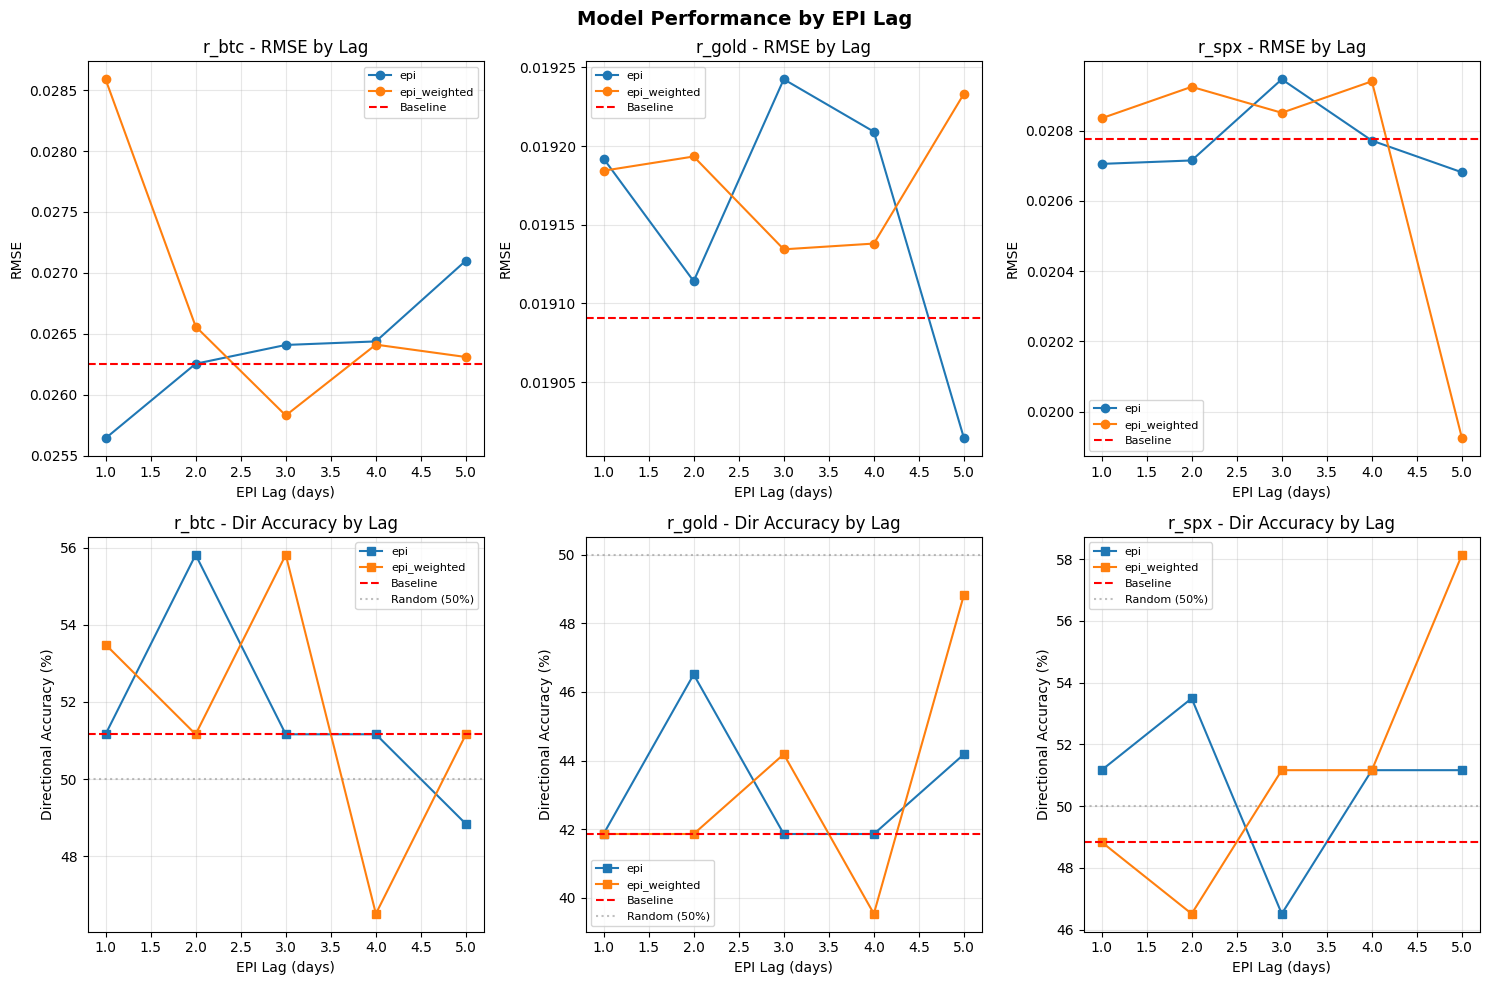


📈 Charts show how model performance varies with EPI lag length.
   - Lines above red dashed line = better than baseline
   - Look for consistent patterns across assets


In [48]:
# ============================================================
# Visualization: Lag Performance Heatmaps
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Model Performance by EPI Lag", fontsize=14, fontweight='bold')

# Plot for each asset
for idx, asset in enumerate(assets):
    # RMSE heatmap data
    asset_data = lag_results_df[lag_results_df["asset"] == asset]
    
    # Plot RMSE by lag
    ax1 = axes[0, idx]
    for epi_type in ["epi", "epi_weighted"]:
        subset = asset_data[asset_data["epi_type"] == epi_type]
        ax1.plot(subset["epi_lag"], subset["rmse"], marker='o', label=epi_type)
    ax1.axhline(y=baseline_results[asset]["rmse"], color='red', linestyle='--', label='Baseline')
    ax1.set_title(f"{asset} - RMSE by Lag")
    ax1.set_xlabel("EPI Lag (days)")
    ax1.set_ylabel("RMSE")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Plot Dir Acc by lag
    ax2 = axes[1, idx]
    for epi_type in ["epi", "epi_weighted"]:
        subset = asset_data[asset_data["epi_type"] == epi_type]
        ax2.plot(subset["epi_lag"], subset["dir_acc"], marker='s', label=epi_type)
    ax2.axhline(y=baseline_results[asset]["dir_acc"], color='red', linestyle='--', label='Baseline')
    ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5, label='Random (50%)')
    ax2.set_title(f"{asset} - Dir Accuracy by Lag")
    ax2.set_xlabel("EPI Lag (days)")
    ax2.set_ylabel("Directional Accuracy (%)")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 Charts show how model performance varies with EPI lag length.")
print("   - Lines above red dashed line = better than baseline")
print("   - Look for consistent patterns across assets")


## 9. (Optional) Event calendar hooks

Here we show a template for adding tariff-event dummies. Adjust dates to match your actual event list.


In [49]:

# Example: create a simple event calendar (replace with real dates)
event_dates = [
    "2025-02-10",  # Initial tariff announcement
    "2025-03-15",  # Another key event
    "2025-04-20",  # Retaliatory tariffs
]

events = pd.DataFrame({
    "event_date": pd.to_datetime(event_dates),
    "event_dummy": 1
}).set_index("event_date")

# Merge into returns as a dummy column
returns_events = returns.join(events["event_dummy"], how="left")
returns_events["event_dummy"] = returns_events["event_dummy"].fillna(0)

returns_events["event_dummy"].value_counts()


event_dummy
0.0000    107
1.0000      1
Name: count, dtype: int64


## 10. Export tidy dataset

We export a panel containing the returns and control variables for reuse in the emotion/EPI notebook.


In [50]:

panel = returns.copy()

# Optionally include event dummies or other flags
# panel = returns_events

panel.to_parquet(FINANCIAL_PANEL_FILE)
panel.to_csv(FINANCIAL_PANEL_CSV)

print("Saved financial panel to:")
print("  ", FINANCIAL_PANEL_FILE)
print("  ", FINANCIAL_PANEL_CSV)


Saved financial panel to:
   ./data/financial_returns_and_controls.parquet
   ./data/financial_returns_and_controls.csv



### Notebook 1 complete ✅

You now have a cleaned financial dataset with returns and control variables saved to disk.
The next notebook will load this panel and merge it with the Emotion and EPI indices.
